# Контрольная работа: анализ текста с помощью моделей семейства BERT

**Дисциплина:** Глубокое обучение / Обработка естественного языка

**Объект анализа:** Л. Н. Толстой, "Война и мир" (английский перевод, Project Gutenberg)

**Задачи контрольной работы:**
1. Загрузка и предобработка текста романа, разбиение по книгам и главам.
2. Распознавание именованных сущностей (NER) -- персоны, организации, географические названия.
3. Извлечение ключевых слов из глав с помощью KeyBERT.
4. Суммаризация текста глав с использованием генеративной модели T5.
5. Тематическое моделирование глав с помощью BERTopic.

**Используемые модели и библиотеки:**

| Задача | Модель / Библиотека | HuggingFace ID | Размер |
|---|---|---|---|
| NER | BERT-base fine-tuned | `dslim/bert-base-NER` | ~440 МБ |
| Ключевые слова | KeyBERT + sentence-transformers | `all-MiniLM-L6-v2` | ~80 МБ |
| Суммаризация | T5-small fine-tuned | `Falconsai/text_summarization` | ~240 МБ |
| Тематическое моделирование | BERTopic + sentence-transformers | `all-MiniLM-L6-v2` | ~80 МБ |

**Требования к среде:** Python 3.8+, GPU не требуется (все модели работают на CPU).

**SEED = 42** (для воспроизводимости результатов).

**Структура блокнота:**
- Часть 0 -- установка зависимостей.
- Часть 1 -- теоретические основы: архитектура BERT и семейство моделей.
- Часть 2 -- загрузка и предобработка текста.
- Часть 3 -- NER: распознавание именованных сущностей.
- Часть 4 -- извлечение ключевых слов (KeyBERT).
- Часть 5 -- суммаризация текста (T5).
- Часть 6 -- тематическое моделирование (BERTopic).
- Часть 7 -- сводный анализ.
- Самостоятельные задания (3 задания с критериями оценки).

---
## Часть 0. Установка зависимостей

Выполните ячейку ниже один раз для установки всех необходимых библиотек.
При повторном запуске блокнота эту ячейку можно пропустить.

In [3]:
# Установка библиотек (выполнить один раз)
# Если библиотеки уже установлены, ячейку можно пропустить.

!pip install -q transformers torch sentencepiece
!pip install -q keybert
!pip install -q bertopic
!pip install -q requests
!pip install -q pandas matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import warnings
warnings.filterwarnings('ignore')

import re
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Все библиотеки успешно импортированы.')

Все библиотеки успешно импортированы.


---
## Часть 1. Теоретические основы: архитектура BERT и семейство моделей

Прежде чем приступить к практическим задачам, необходимо понять,
как устроена модель BERT и почему она стала основой для множества задач NLP.

### 1.1. Что такое BERT

**BERT** (Bidirectional Encoder Representations from Transformers) -- это предобученная
языковая модель, предложенная исследователями Google в 2018 году
(Devlin et al., "BERT: Pre-training of Deep Bidirectional Transformers for
Language Understanding", 2019).

Ключевые особенности BERT:

- **Двунаправленность.** В отличие от предшествующих моделей (GPT-1 читает текст слева направо,
  ELMo использует конкатенацию двух однонаправленных LSTM), BERT обрабатывает весь контекст
  одновременно -- как левый, так и правый. Это достигается благодаря механизму self-attention
  в архитектуре Transformer.

- **Предобучение + дообучение (pre-training + fine-tuning).** BERT сначала предобучается на
  большом корпусе неразмеченного текста (Wikipedia + BookCorpus, ~3.3 млрд слов), а затем
  дообучается на конкретной задаче с небольшим количеством размеченных данных.

- **Универсальность.** Одна и та же предобученная модель может быть дообучена для классификации
  текстов, распознавания именованных сущностей, ответов на вопросы, суммаризации и других задач.

### 1.2. Архитектура Transformer (encoder)

BERT использует только **encoder-часть** архитектуры Transformer (Vaswani et al., 2017).

Каждый слой encoder содержит два подслоя:

**1) Multi-Head Self-Attention.**
Механизм самовнимания позволяет каждому токену "смотреть" на все остальные токены
в последовательности и формировать свое представление с учетом контекста.

Для входной последовательности x = (x_1, ..., x_n) вычисляются три матрицы:
- Q = x * W_Q (запросы, queries)
- K = x * W_K (ключи, keys)
- V = x * W_V (значения, values)

Матрица внимания:

    Attention(Q, K, V) = softmax(Q * K^T / sqrt(d_k)) * V

где d_k -- размерность ключей. Деление на sqrt(d_k) стабилизирует градиенты.

Multi-Head Attention использует h независимых "голов" внимания, каждая из которых
обучается выделять разные типы зависимостей (синтаксические, семантические и др.).
Результаты голов конкатенируются и проецируются:

    MultiHead(Q, K, V) = Concat(head_1, ..., head_h) * W_O

**2) Feed-Forward Network (FFN).**
Двухслойная полносвязная сеть с нелинейностью GELU:

    FFN(x) = GELU(x * W_1 + b_1) * W_2 + b_2

Каждый подслой окружен **residual connection** и **layer normalization**:

    output = LayerNorm(x + Sublayer(x))

**Варианты модели BERT:**

| Параметр | BERT-base | BERT-large |
|---|---|---|
| Слоев (L) | 12 | 24 |
| Скрытая размерность (H) | 768 | 1024 |
| Голов внимания (A) | 12 | 16 |
| Параметров | 110M | 340M |

### 1.3. Токенизация: WordPiece

BERT использует **WordPiece-токенизацию** -- метод подсловной токенизации,
при котором слова разбиваются на подслова из фиксированного словаря (~30 000 токенов).

Пример: слово "Bolkonski" может быть разбито на: `["Bol", "##kon", "##ski"]`

Префикс `##` означает, что данный подтокен -- продолжение предыдущего слова.

Специальные токены BERT:
- `[CLS]` -- специальный токен в начале последовательности.
  Его выходной вектор используется как представление всей последовательности
  (например, для классификации).
- `[SEP]` -- разделитель между двумя предложениями.
- `[PAD]` -- заполнитель для выравнивания последовательностей до одинаковой длины.
- `[MASK]` -- токен, используемый при предобучении (задача MLM).

**Ограничение:** максимальная длина входа BERT -- **512 токенов**.
Это важно при работе с длинными текстами: главы романа необходимо разбивать на фрагменты.

### 1.4. Предобучение BERT: MLM и NSP

BERT предобучается на двух задачах одновременно:

**1) Masked Language Modeling (MLM) -- маскированное языковое моделирование.**

15% токенов входной последовательности случайным образом заменяются:
- 80% -- на токен `[MASK]`
- 10% -- на случайный токен из словаря
- 10% -- остаются без изменений

Модель обучается предсказывать исходные замаскированные токены.
Это вынуждает BERT использовать двунаправленный контекст.

Пример:
- Вход: `"Prince [MASK] arrived at the [MASK] headquarters."`
- Цель: `"Andrew"`, `"Russian"`

**2) Next Sentence Prediction (NSP) -- предсказание следующего предложения.**

Модель получает пару предложений (A, B) и предсказывает,
является ли B реальным продолжением A (IsNext) или случайным предложением (NotNext).

В последующих работах (RoBERTa, ALBERT) было показано, что задача NSP
не всегда полезна и может быть заменена другими стратегиями.

### 1.5. Дообучение BERT для конкретных задач (fine-tuning)

После предобучения BERT адаптируется к конкретной задаче добавлением
одного или нескольких слоев поверх выходных представлений:

**Классификация последовательности** (sentiment analysis, text classification):
- Используется выход `[CLS]`-токена.
- Добавляется линейный слой: `y = softmax(W * h_CLS + b)`.

**Классификация токенов** (NER, POS-tagging):
- Используются выходы каждого токена.
- Добавляется линейный слой поверх каждого токена: `y_i = softmax(W * h_i + b)`.

**Извлечение ответа** (question answering):
- Модель предсказывает позиции начала и конца ответа в тексте.

В данной контрольной работе мы используем готовые дообученные модели
из HuggingFace Hub, не выполняя дообучение самостоятельно.

### 1.6. Семейство BERT: основные варианты

На основе архитектуры BERT было создано множество моделей:

| Модель | Год | Отличие от BERT | Типичное применение |
|---|---|---|---|
| **RoBERTa** | 2019 | Больше данных, нет NSP, динамическое маскирование | Классификация, NER |
| **DistilBERT** | 2019 | 40% меньше параметров, на 60% быстрее, 97% качества | Быстрый inference |
| **ALBERT** | 2019 | Факторизация эмбеддингов, общие параметры между слоями | Экономия памяти |
| **Sentence-BERT** | 2019 | Сиамская сеть для эмбеддингов предложений | Семантический поиск |
| **T5** | 2019 | Encoder-decoder, все задачи как text-to-text | Генерация, суммаризация |
| **DeBERTa** | 2020 | Раздельное кодирование позиций и содержания | Сильная базовая модель |

В данной работе мы используем:
- **BERT-base** (encoder-only) -- для NER.
- **MiniLM** (дистиллированная Sentence-BERT) -- для эмбеддингов предложений.
- **T5-small** (encoder-decoder) -- для генеративной суммаризации.

### 1.7. HuggingFace Transformers: пайплайны

Библиотека `transformers` от HuggingFace предоставляет высокоуровневый интерфейс
**pipeline** для решения типовых задач NLP без написания кода обучения.

Пайплайн автоматически выполняет:
1. Загрузку предобученной модели и токенизатора из HuggingFace Hub.
2. Предобработку входного текста (токенизация, padding, attention mask).
3. Прямой проход модели (inference).
4. Постобработку выхода (декодирование, агрегация подтокенов).

Основные пайплайны, используемые в работе:

```python
from transformers import pipeline

# NER -- классификация токенов
ner = pipeline('ner', model='...', aggregation_strategy='simple')

# Суммаризация -- генерация текста (seq2seq, Transformers v5+)
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
tokenizer = AutoTokenizer.from_pretrained('Falconsai/text_summarization')
model = AutoModelForSeq2SeqLM.from_pretrained('Falconsai/text_summarization')
```

Параметр `aggregation_strategy='simple'` в NER-пайплайне важен:
он объединяет подтокены WordPiece обратно в целые слова.
Например, подтокены `["Bol", "##kon", "##ski"]` с метками `[B-PER, I-PER, I-PER]`
будут объединены в одну сущность `"Bolkonski"` типа PER.

---
## Часть 2. Загрузка и предобработка текста

### Описание данных

В качестве корпуса для анализа используется роман Л. Н. Толстого "Война и мир"
(английский перевод Луизы и Эйлмера Мод, 1922-1942). Текст находится в общественном
достоянии и доступен на Project Gutenberg (EBook #2600).

**Характеристики текста:**
- Примерный объем: ~3.2 МБ, ~580 000 слов.
- Структура: 15 книг (Books One -- Fifteen), First Epilogue, Second Epilogue.
- Каждая книга содержит от 13 до 39 глав.
- Язык: английский (с вкраплениями французского, как в оригинале).

**Почему английский перевод, а не оригинал?**
Большинство предобученных моделей BERT на HuggingFace оптимизированы для английского языка.
Использование английского текста позволяет применять легкие модели без мультиязычных
компонентов, что снижает требования к вычислительным ресурсам.

**Этапы предобработки:**
1. Загрузка полного текста из Project Gutenberg.
2. Удаление служебной информации (лицензия, метаданные Gutenberg).
3. Разбиение на книги и главы с помощью регулярных выражений.
4. Формирование структурированного датафрейма.

### 2.1. Загрузка текста из Project Gutenberg

In [5]:
url = 'https://www.gutenberg.org/ebooks/2600.txt.utf-8'
response = requests.get(url)
response.encoding = 'utf-8'
full_text = response.text

print(f'Общий размер текста: {len(full_text):,} символов')
print(f'Первые 500 символов:\n{full_text[:500]}')

Общий размер текста: 3,293,656 символов
Первые 500 символов:
﻿The Project Gutenberg eBook of War and Peace
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook


### 2.2. Очистка: удаление заголовков и лицензии Gutenberg

In [6]:
# Находим начало и конец собственно текста романа
start_marker = '*** START OF THE PROJECT GUTENBERG EBOOK'
end_marker = '*** END OF THE PROJECT GUTENBERG EBOOK'

start_idx = full_text.find(start_marker)
if start_idx != -1:
    start_idx = full_text.index('\n', start_idx) + 1
else:
    start_idx = 0

end_idx = full_text.find(end_marker)
if end_idx == -1:
    end_idx = len(full_text)

novel_text = full_text[start_idx:end_idx].strip()
print(f'Размер текста романа (без служебной информации): {len(novel_text):,} символов')

Размер текста романа (без служебной информации): 3,273,921 символов


### 2.3. Разбиение текста на книги и главы

In [7]:
def split_into_books_and_chapters(text):
    """
    Разбивает текст романа на книги и главы.
    Возвращает словарь: {book_name: {chapter_name: chapter_text}}
    """
    # Паттерн для книг: BOOK ONE: 1805, FIRST EPILOGUE, SECOND EPILOGUE
    book_pattern = re.compile(
        r'^(BOOK\s+\w+:.*|FIRST EPILOGUE.*|SECOND EPILOGUE.*)$',
        re.MULTILINE
    )
    # Паттерн для глав: CHAPTER I, CHAPTER II, ...
    chapter_pattern = re.compile(r'^(CHAPTER\s+[IVXLC]+)\s*$', re.MULTILINE)

    # Находим все книги
    book_matches = list(book_pattern.finditer(text))
    books = {}

    for i, bm in enumerate(book_matches):
        book_name = bm.group(1).strip()
        book_start = bm.end()
        book_end = book_matches[i + 1].start() if i + 1 < len(book_matches) else len(text)
        book_text = text[book_start:book_end]

        # Находим главы внутри книги
        ch_matches = list(chapter_pattern.finditer(book_text))
        chapters = {}
        for j, cm in enumerate(ch_matches):
            ch_name = cm.group(1).strip()
            ch_start = cm.end()
            ch_end = ch_matches[j + 1].start() if j + 1 < len(ch_matches) else len(book_text)
            ch_text = book_text[ch_start:ch_end].strip()
            if len(ch_text) > 100:  # Отсекаем пустые/слишком короткие
                chapters[ch_name] = ch_text

        if chapters:
            books[book_name] = chapters

    return books


books = split_into_books_and_chapters(novel_text)

# Статистика
print(f'Найдено книг: {len(books)}')
total_chapters = sum(len(chs) for chs in books.values())
print(f'Всего глав: {total_chapters}')
print()
for book_name, chapters in books.items():
    avg_len = int(np.mean([len(t) for t in chapters.values()]))
    print(f'  {book_name}: {len(chapters)} глав, средняя длина {avg_len:,} символов')

Найдено книг: 17
Всего глав: 365

  BOOK ONE: 1805: 28 глав, средняя длина 9,880 символов
  BOOK TWO: 1805: 21 глав, средняя длина 11,322 символов
  BOOK THREE: 1805: 19 глав, средняя длина 13,418 символов
  BOOK FOUR: 1806: 16 глав, средняя длина 8,414 символов
  BOOK FIVE: 1806 - 07: 22 глав, средняя длина 8,755 символов
  BOOK SIX: 1808 - 10: 26 глав, средняя длина 7,393 символов
  BOOK SEVEN: 1810 - 11: 13 глав, средняя длина 10,091 символов
  BOOK EIGHT: 1811 - 12: 22 глав, средняя длина 8,125 символов
  BOOK NINE: 1812: 23 глав, средняя длина 9,600 символов
  BOOK TEN: 1812: 39 глав, средняя длина 9,627 символов
  BOOK ELEVEN: 1812: 34 глав, средняя длина 8,820 символов
  BOOK TWELVE: 1812: 16 глав, средняя длина 8,759 символов
  BOOK THIRTEEN: 1812: 19 глав, средняя длина 6,232 символов
  BOOK FOURTEEN: 1812: 19 глав, средняя длина 6,276 символов
  BOOK FIFTEEN: 1812 - 13: 20 глав, средняя длина 7,025 символов
  FIRST EPILOGUE: 1813 - 20: 16 глав, средняя длина 8,678 символов
  

### 2.4. Формирование плоского списка глав

Для удобства дальнейшей работы создадим DataFrame с метаинформацией о каждой главе:
название книги, название главы, текст главы, длина текста.

In [8]:
chapters_list = []
for book_name, chapters in books.items():
    for ch_name, ch_text in chapters.items():
        chapters_list.append({
            'book': book_name,
            'chapter': ch_name,
            'text': ch_text,
            'length': len(ch_text)
        })

df_chapters = pd.DataFrame(chapters_list)
print(f'Всего глав в датафрейме: {len(df_chapters)}')
print(f'Общий объем текста: {df_chapters["length"].sum():,} символов')
print(f'Средняя длина главы: {df_chapters["length"].mean():,.0f} символов')
print(f'Медиана длины главы: {df_chapters["length"].median():,.0f} символов')
df_chapters[['book', 'chapter', 'length']].head(10)

Всего глав в датафрейме: 365
Общий объем текста: 3,256,226 символов
Средняя длина главы: 8,921 символов
Медиана длины главы: 8,141 символов


,book,chapter,length
0,BOOK ONE: 1805,CHAPTER I,11666
1,BOOK ONE: 1805,CHAPTER II,7910
2,BOOK ONE: 1805,CHAPTER III,8730
3,BOOK ONE: 1805,CHAPTER IV,8164
4,BOOK ONE: 1805,CHAPTER V,11253
5,BOOK ONE: 1805,CHAPTER VI,7882
6,BOOK ONE: 1805,CHAPTER VII,5806
7,BOOK ONE: 1805,CHAPTER VIII,6882
8,BOOK ONE: 1805,CHAPTER IX,12224
9,BOOK ONE: 1805,CHAPTER X,9833


### 2.5. Распределение длин глав

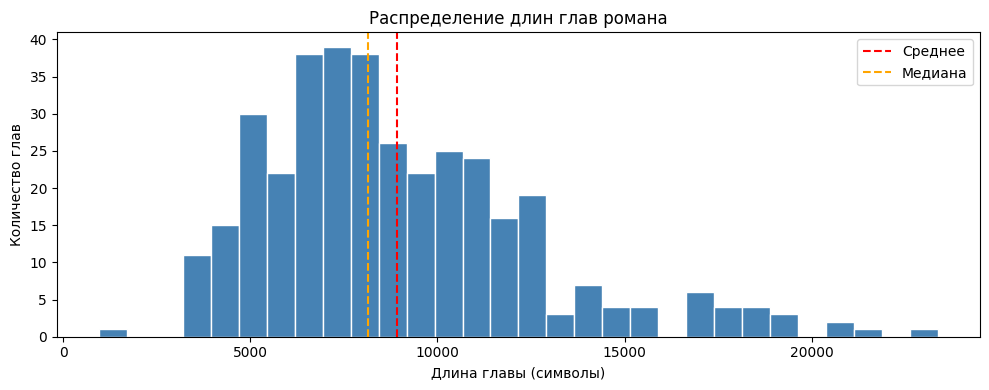

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_chapters['length'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(df_chapters['length'].mean(), color='red', linestyle='--', label='Среднее')
ax.axvline(df_chapters['length'].median(), color='orange', linestyle='--', label='Медиана')
ax.set_xlabel('Длина главы (символы)')
ax.set_ylabel('Количество глав')
ax.set_title('Распределение длин глав романа')
ax.legend()
plt.tight_layout()
plt.show()

---
## Часть 3. Распознавание именованных сущностей (NER)

### 3.0. Теоретические основы задачи NER

#### Формальная постановка задачи

**Named Entity Recognition (NER)** -- задача последовательной классификации (sequence labeling),
в которой каждому токену входной последовательности присваивается метка,
указывающая, принадлежит ли он именованной сущности и к какому типу.

Формально: дана последовательность токенов x = (x_1, x_2, ..., x_n).
Требуется найти последовательность меток y = (y_1, y_2, ..., y_n),
где y_i принадлежит множеству допустимых тегов.

#### BIO-разметка (Begin, Inside, Outside)

Стандартная схема разметки NER -- **BIO** (также называемая IOB2):

- **B-TYPE** -- начало сущности типа TYPE.
- **I-TYPE** -- продолжение сущности типа TYPE.
- **O** -- токен не является частью именованной сущности.

Пример:

| Токен | Prince | Andrew | Bolkonski | arrived | at | the | Russian | headquarters |
|---|---|---|---|---|---|---|---|---|
| BIO-тег | B-PER | I-PER | I-PER | O | O | O | B-MISC | O |

Здесь "Prince Andrew Bolkonski" -- одна сущность типа PER (персона),
а "Russian" -- сущность типа MISC (прочее).

Существуют также расширенные схемы:
- **BIOES** (Begin, Inside, Outside, End, Single) -- добавляет теги E (конец) и S (одиночная).
- **BILOU** -- аналогичная схема с другими именами тегов.

#### Архитектура BERT для NER

Для задачи NER к предобученному BERT добавляется **классификационная голова** --
линейный слой поверх выходных представлений каждого токена:

    y_i = softmax(W * h_i + b)

где h_i -- выходной вектор i-го токена из последнего слоя BERT (размерность 768 для base),
W -- матрица весов классификатора (768 x num_labels),
num_labels -- количество BIO-тегов.

В более продвинутых моделях поверх BERT добавляется **слой CRF** (Conditional Random Field),
который моделирует зависимости между соседними метками.
Например, CRF запрещает переход I-ORG после B-PER, поскольку это нарушает структуру BIO.

Модель `dslim/bert-base-NER` использует простой линейный классификатор без CRF,
что делает ее быстрой и достаточно точной для большинства задач.

#### Датасет CoNLL-2003

Модель `dslim/bert-base-NER` дообучена на английской части датасета CoNLL-2003 --
стандартном бенчмарке для NER. Датасет содержит новостные тексты Reuters с разметкой
четырех типов сущностей:

| Тип | Описание | Примеры |
|---|---|---|
| **PER** | Персоны | "Napoleon", "Kutuzov", "Anna Pavlovna" |
| **ORG** | Организации | "Guards", "Senate", "English Club" |
| **LOC** | Географические | "Moscow", "Austerlitz", "Russia" |
| **MISC** | Прочие | "French", "Russian", "Christian" |

Метрики модели на CoNLL-2003 test set:
- F1-score: ~91.3%

#### Проблема длинных текстов

Ограничение BERT в 512 токенов создает проблему при работе с длинными документами.
Существует несколько стратегий:

1. **Разбиение с перекрытием (sliding window).** Текст делится на фрагменты
   фиксированной длины с перекрытием, чтобы сущности на границах не терялись.
   Мы используем именно этот подход.

2. **Longformer / BigBird.** Модели с эффективным механизмом внимания,
   позволяющие обрабатывать до 4096+ токенов.

3. **Иерархические модели.** Обработка на уровне предложений с последующей
   агрегацией результатов.

### 3.1. Загрузка модели NER

Загружаем пайплайн `ner` с моделью `dslim/bert-base-NER`.
Параметр `aggregation_strategy='simple'` указывает пайплайну
объединять подтокены WordPiece (например, `["Bol", "##kon", "##ski"]`)
обратно в целые слова.

In [10]:
from transformers import pipeline

# Загрузка пайплайна NER
# aggregation_strategy='simple' -- объединяет подтокены (##) в единую сущность
ner_pipeline = pipeline(
    'ner',
    model='dslim/bert-base-NER',
    aggregation_strategy='simple'
)

# Проверка на коротком тексте
test_text = 'Prince Andrew Bolkonski arrived at the Russian headquarters in Olmutz.'
test_entities = ner_pipeline(test_text)

print('Результат NER для тестового предложения:')
print(f'  Текст: "{test_text}"')
print()
for ent in test_entities:
    print(f'  {ent["entity_group"]:5s} | {ent["word"]:30s} | score={ent["score"]:.3f}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 444.26it/s, Materializing param=classifier.weight]                                      
BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Результат NER для тестового предложения:
  Текст: "Prince Andrew Bolkonski arrived at the Russian headquarters in Olmutz."

  PER   | Andrew Bolkonski               | score=0.945
  MISC  | Russian                        | score=1.000
  LOC   | Olmutz                         | score=0.901


### 3.2. Функции извлечения сущностей

Определим две вспомогательные функции:

- `extract_entities_from_text()` -- разбивает длинный текст на фрагменты
  (sliding window, chunk_size=450, overlap=50) и применяет NER к каждому.
  Перекрытие в 50 символов снижает вероятность потери сущностей на границах.

- `group_entities()` -- группирует найденные сущности по типу
  и подсчитывает частоту каждой уникальной сущности.

In [11]:
def extract_entities_from_text(text, ner_pipe, chunk_size=450, overlap=50):
    """
    Извлекает именованные сущности из длинного текста,
    разбивая его на перекрывающиеся фрагменты.

    Параметры:
        text         -- входной текст (может быть длинным)
        ner_pipe     -- пайплайн NER из transformers
        chunk_size   -- размер фрагмента в символах (по умолчанию 450)
        overlap      -- перекрытие между соседними фрагментами

    Возвращает:
        Список словарей с найденными сущностями.
    """
    entities = []
    step = chunk_size - overlap
    for i in range(0, len(text), step):
        chunk = text[i:i + chunk_size]
        try:
            chunk_entities = ner_pipe(chunk)
            entities.extend(chunk_entities)
        except Exception:
            continue
    return entities


def group_entities(entities):
    """
    Группирует сущности по типу (PER, ORG, LOC, MISC).

    Возвращает:
        Словарь {тип: Counter(сущность -> количество)}.
    """
    grouped = defaultdict(Counter)
    for ent in entities:
        word = ent['word'].strip()
        if len(word) > 1:  # Отсекаем однобуквенные артефакты
            grouped[ent['entity_group']][word] += 1
    return dict(grouped)


print('Функции extract_entities_from_text и group_entities определены.')

Функции extract_entities_from_text и group_entities определены.


### 3.3. Обработка первых 5 глав (демонстрация)

Для экономии времени в контрольной работе обработаем первые 5 глав Book One.
Полная обработка всех ~330 глав займет значительное время (~30-60 минут на CPU),
поэтому в самостоятельных заданиях предлагается обработать одну книгу целиком.

In [12]:
# Обрабатываем первые 5 глав
sample_chapters = df_chapters.head(5)
all_entities_by_chapter = []

for idx, row in sample_chapters.iterrows():
    print(f'Обработка: {row["book"]}, {row["chapter"]} ({row["length"]:,} символов)...')
    entities = extract_entities_from_text(row['text'], ner_pipeline)
    grouped = group_entities(entities)
    all_entities_by_chapter.append({
        'book': row['book'],
        'chapter': row['chapter'],
        'entities': grouped
    })
    # Краткая статистика
    for etype, counter in grouped.items():
        print(f'    {etype}: {sum(counter.values())} упоминаний, {len(counter)} уникальных')

print('\nГотово.')

Обработка: BOOK ONE: 1805, CHAPTER I (11,666 символов)...
    LOC: 16 упоминаний, 11 уникальных
    PER: 87 упоминаний, 48 уникальных
    MISC: 9 упоминаний, 5 уникальных
    ORG: 1 упоминаний, 1 уникальных
Обработка: BOOK ONE: 1805, CHAPTER II (7,910 символов)...
    PER: 75 упоминаний, 28 уникальных
    LOC: 7 упоминаний, 5 уникальных
    MISC: 2 упоминаний, 1 уникальных
Обработка: BOOK ONE: 1805, CHAPTER III (8,730 символов)...
    PER: 67 упоминаний, 27 уникальных
    LOC: 5 упоминаний, 4 уникальных
    ORG: 1 упоминаний, 1 уникальных
    MISC: 3 упоминаний, 2 уникальных
Обработка: BOOK ONE: 1805, CHAPTER IV (8,164 символов)...
    PER: 105 упоминаний, 45 уникальных
    MISC: 3 упоминаний, 1 уникальных
    LOC: 5 упоминаний, 3 уникальных
    ORG: 4 упоминаний, 1 уникальных
Обработка: BOOK ONE: 1805, CHAPTER V (11,253 символов)...
    LOC: 13 упоминаний, 10 уникальных
    PER: 100 упоминаний, 32 уникальных
    MISC: 31 упоминаний, 16 уникальных

Готово.


### 3.4. Визуализация: топ-15 сущностей каждого типа

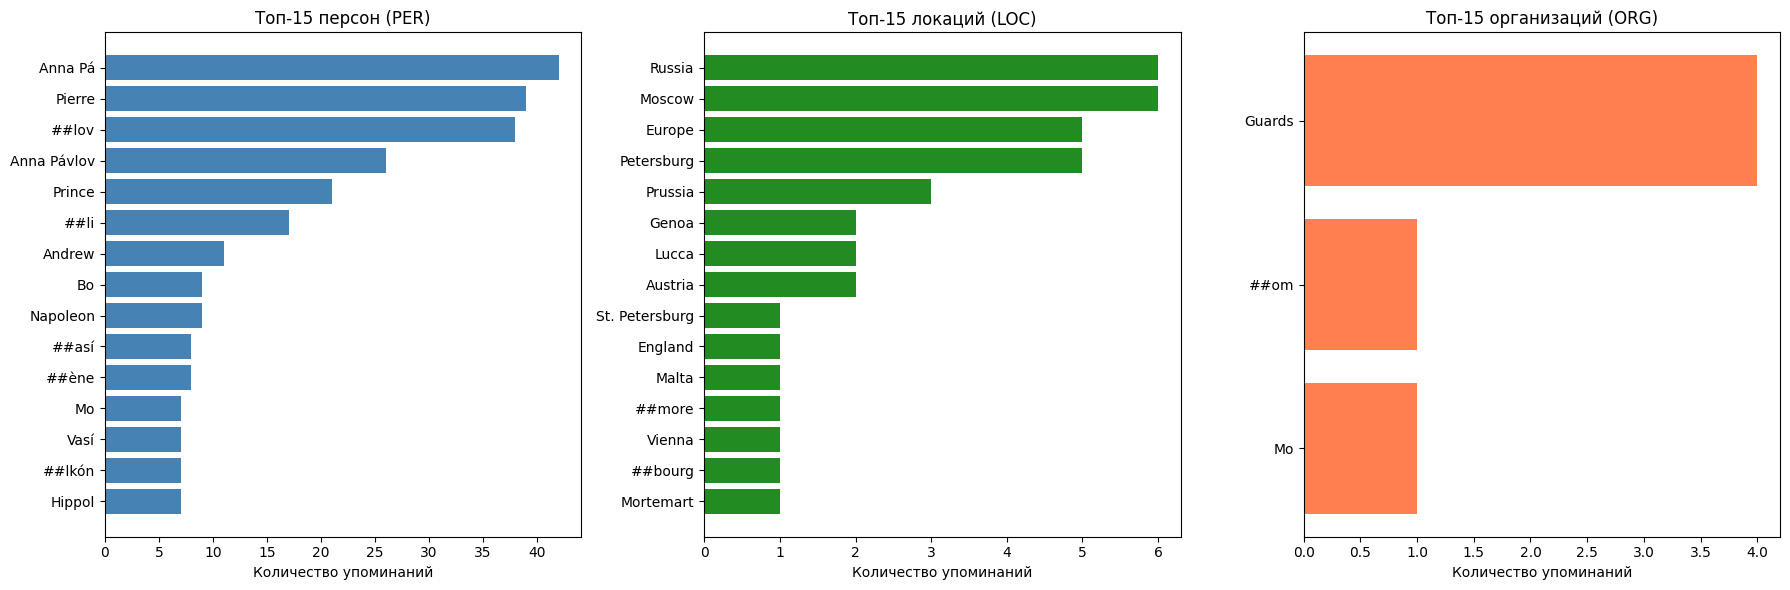

In [13]:
# Объединяем все сущности из обработанных глав
all_persons = Counter()
all_locations = Counter()
all_orgs = Counter()

for ch_data in all_entities_by_chapter:
    ents = ch_data['entities']
    if 'PER' in ents:
        all_persons.update(ents['PER'])
    if 'LOC' in ents:
        all_locations.update(ents['LOC'])
    if 'ORG' in ents:
        all_orgs.update(ents['ORG'])

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Персоны
top_persons = all_persons.most_common(15)
if top_persons:
    names, counts = zip(*top_persons)
    axes[0].barh(range(len(names)), counts, color='steelblue')
    axes[0].set_yticks(range(len(names)))
    axes[0].set_yticklabels(names)
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Количество упоминаний')
    axes[0].set_title('Топ-15 персон (PER)')

# Локации
top_locs = all_locations.most_common(15)
if top_locs:
    names, counts = zip(*top_locs)
    axes[1].barh(range(len(names)), counts, color='forestgreen')
    axes[1].set_yticks(range(len(names)))
    axes[1].set_yticklabels(names)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Количество упоминаний')
    axes[1].set_title('Топ-15 локаций (LOC)')

# Организации
top_orgs = all_orgs.most_common(15)
if top_orgs:
    names, counts = zip(*top_orgs)
    axes[2].barh(range(len(names)), counts, color='coral')
    axes[2].set_yticks(range(len(names)))
    axes[2].set_yticklabels(names)
    axes[2].invert_yaxis()
    axes[2].set_xlabel('Количество упоминаний')
    axes[2].set_title('Топ-15 организаций (ORG)')

plt.tight_layout()
plt.show()

### 3.5. Таблица сущностей по главам

In [14]:
# Сводная таблица: количество уникальных сущностей каждого типа по главам
rows = []
for ch_data in all_entities_by_chapter:
    ents = ch_data['entities']
    rows.append({
        'Книга': ch_data['book'],
        'Глава': ch_data['chapter'],
        'PER (уник.)': len(ents.get('PER', {})),
        'LOC (уник.)': len(ents.get('LOC', {})),
        'ORG (уник.)': len(ents.get('ORG', {})),
        'MISC (уник.)': len(ents.get('MISC', {})),
    })

df_ner_summary = pd.DataFrame(rows)
df_ner_summary

,Книга,Глава,PER (уник.),LOC (уник.),ORG (уник.),MISC (уник.)
0,BOOK ONE: 1805,CHAPTER I,48,11,1,5
1,BOOK ONE: 1805,CHAPTER II,28,5,0,1
2,BOOK ONE: 1805,CHAPTER III,27,4,1,2
3,BOOK ONE: 1805,CHAPTER IV,45,3,1,1
4,BOOK ONE: 1805,CHAPTER V,32,10,0,16


---
## Часть 4. Извлечение ключевых слов (KeyBERT)

### 4.0. Теоретические основы

#### Постановка задачи извлечения ключевых слов

**Извлечение ключевых слов** (keyword extraction) -- задача автоматического определения
наиболее важных слов или фраз, характеризующих содержание документа.

В отличие от генеративных подходов (keyphrase generation), при извлечении
ключевые слова берутся непосредственно из текста документа.

#### Традиционные методы

| Метод | Принцип | Ограничения |
|---|---|---|
| **TF-IDF** | Статистика частот слов в документе vs корпусе | Не учитывает семантику, зависит от корпуса |
| **RAKE** | Графовый: co-occurrence частот кандидатов | Не учитывает контекст, часто шумные результаты |
| **YAKE!** | Статистические признаки позиции и частоты | Не учитывает семантику |
| **TextRank** | PageRank на графе ко-вхождений слов | Ограничен лексической ко-встречаемостью |

Все традиционные методы основаны на **лексической статистике** и не учитывают
семантическое значение слов.

#### Подход KeyBERT

KeyBERT (Grootendorst, 2020) использует принципиально другой подход,
основанный на **семантическом сходстве эмбеддингов**:

1. **Документ-эмбеддинг.** Весь документ преобразуется в один вектор
   с помощью модели sentence-transformers (например, `all-MiniLM-L6-v2`).

2. **Кандидат-эмбеддинги.** Все N-граммы (от 1 до n слов)
   из документа преобразуются в векторы той же моделью.

3. **Ранжирование.** Кандидаты ранжируются по **косинусному сходству**
   с эмбеддингом документа:

       cos(a, b) = (a . b) / (||a|| * ||b||)

   Чем выше сходство N-граммы с документом, тем лучше она описывает его содержание.

4. **Диверсификация (MMR).** Для снижения избыточности используется
   **Maximal Marginal Relevance** -- алгоритм, который при выборе следующего
   ключевого слова учитывает не только его релевантность документу,
   но и непохожесть на уже выбранные ключевые слова:

       MMR = argmax [lambda * sim(kw, doc) - (1-lambda) * max_j sim(kw, kw_j)]

   Параметр `diversity` в KeyBERT контролирует lambda (0 = только релевантность,
   1 = только разнообразие).

#### Модель all-MiniLM-L6-v2

`all-MiniLM-L6-v2` -- легкая модель из библиотеки sentence-transformers:
- Архитектура: 6 слоев MiniLM (дистиллированный BERT).
- Размерность эмбеддинга: 384.
- Размер: ~80 МБ.
- Обучена на > 1 млрд пар предложений из разных доменов.
- Подходит для семантического поиска, кластеризации, извлечения ключевых слов.

### 4.1. Инициализация KeyBERT

In [15]:
from keybert import KeyBERT

# Используем легкую модель sentence-transformers
kw_model = KeyBERT(model='all-MiniLM-L6-v2')

# Проверка
test_keywords = kw_model.extract_keywords(
    'Napoleon invaded Russia in 1812 with a massive army. '
    'The French forces crossed the Niemen river and marched towards Moscow.',
    keyphrase_ngram_range=(1, 2),
    top_n=5,
    use_mmr=True,
    diversity=0.5
)
print('Ключевые слова (тест):')
for kw, score in test_keywords:
    print(f'  {kw:30s} | cosine_similarity={score:.3f}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 433.79it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ключевые слова (тест):
  napoleon invaded               | cosine_similarity=0.694
  russia 1812                    | cosine_similarity=0.636
  marched moscow                 | cosine_similarity=0.504
  niemen river                   | cosine_similarity=0.383
  forces crossed                 | cosine_similarity=0.269


### 4.2. Извлечение ключевых слов для первых 5 глав

Для каждой главы извлекаем 10 ключевых слов (униграммы и биграммы)
с использованием MMR для диверсификации (diversity=0.5).

Параметры:
- `keyphrase_ngram_range=(1, 2)` -- кандидаты: отдельные слова и пары слов.
- `stop_words='english'` -- исключение стоп-слов (the, a, is, ...).
- `use_mmr=True` -- Maximal Marginal Relevance для разнообразия.
- `diversity=0.5` -- баланс между релевантностью и разнообразием.

In [16]:
keywords_by_chapter = []

for idx, row in sample_chapters.iterrows():
    print(f'Обработка: {row["book"]}, {row["chapter"]}...')

    # Извлекаем ключевые слова (униграммы и биграммы)
    keywords = kw_model.extract_keywords(
        row['text'],
        keyphrase_ngram_range=(1, 2),
        stop_words='english',
        top_n=10,
        use_mmr=True,        # Maximal Marginal Relevance для разнообразия
        diversity=0.5
    )

    keywords_by_chapter.append({
        'book': row['book'],
        'chapter': row['chapter'],
        'keywords': keywords
    })

    # Выводим топ-5
    for kw, score in keywords[:5]:
        print(f'    {kw:30s} | {score:.3f}')
    print()

print('Готово.')

Обработка: BOOK ONE: 1805, CHAPTER I...
    anna pávlovna                  | 0.496
    criticize empress              | 0.436
    slave frightened               | 0.335
    buonapartes warn               | 0.325
    prince genoa                   | 0.297

Обработка: BOOK ONE: 1805, CHAPTER II...
    princess bolkónskaya           | 0.560
    woman petersburg               | 0.545
    vasíli daughter                | 0.444
    arrival anna                   | 0.432
    hélène came                    | 0.377

Обработка: BOOK ONE: 1805, CHAPTER III...
    pávlovna guests                | 0.549
    lady careworn                  | 0.462
    round mortemart                | 0.383
    princess rested                | 0.368
    maître hôtel                   | 0.357

Обработка: BOOK ONE: 1805, CHAPTER IV...
    princess husband               | 0.518
    bolkónski speaking             | 0.403
    pávlovna smiled                | 0.398
    turning anna                   | 0.335
    borís adjuta

### 4.3. Визуализация ключевых слов

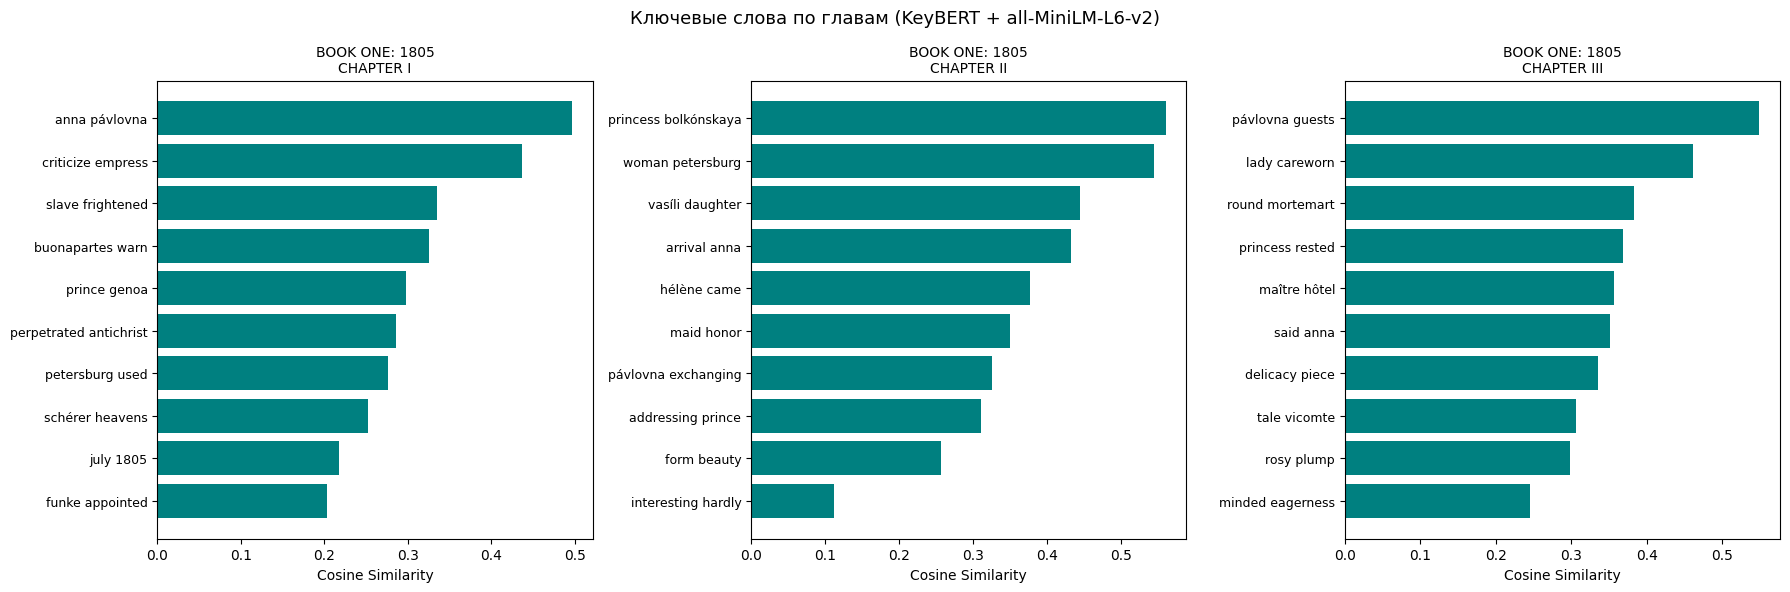

In [17]:
# Визуализация для первых 3 глав
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ch_data in enumerate(keywords_by_chapter[:3]):
    kws = ch_data['keywords']
    words = [kw for kw, _ in kws]
    scores = [score for _, score in kws]

    axes[i].barh(range(len(words)), scores, color='teal')
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words, fontsize=9)
    axes[i].invert_yaxis()
    axes[i].set_xlabel('Cosine Similarity')
    axes[i].set_title(f'{ch_data["book"]}\n{ch_data["chapter"]}', fontsize=10)

plt.suptitle('Ключевые слова по главам (KeyBERT + all-MiniLM-L6-v2)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Часть 5. Суммаризация текста глав

### 5.0. Теоретические основы

#### Экстрактивная vs абстрактивная суммаризация

Суммаризация текста бывает двух видов:

**Экстрактивная суммаризация** -- выбор наиболее важных предложений из исходного текста
и их компоновка в сводку. Текст сводки полностью состоит из фрагментов оригинала.
Методы: TextRank, LexRank, BertSumExt.

**Абстрактивная суммаризация** -- генерация нового текста, который пересказывает
содержание оригинала своими словами. Может содержать слова и фразы, отсутствующие
в исходном тексте. Требует генеративных моделей (encoder-decoder).

В данной работе мы используем **абстрактивную суммаризацию** на основе модели T5.

#### Архитектура T5 (Text-to-Text Transfer Transformer)

T5 (Raffel et al., 2019) -- модель, которая формулирует все задачи NLP
как преобразование текста в текст (text-to-text).

В отличие от BERT (только encoder), T5 имеет **encoder-decoder** архитектуру:

- **Encoder** обрабатывает входной текст и формирует контекстные представления.
- **Decoder** генерирует выходной текст токен за токеном, используя:
  - Self-attention (внимание к уже сгенерированным токенам).
  - Cross-attention (внимание к выходам encoder).

Для суммаризации входной текст подается с префиксом `"summarize: "`:

    Вход:  "summarize: Anna Pavlovna Scherer arranged an evening party..."
    Выход: "Anna Pavlovna hosted a social gathering to discuss European politics."

**T5-small** -- наименьшая версия (60 МБ, 6 слоев encoder + 6 слоев decoder).
Модель `Falconsai/text_summarization` -- T5-small, дообученная на задаче суммаризации.

#### Стратегия декодирования

При генерации текста модель на каждом шаге выбирает следующий токен.
Основные стратегии:

- **Greedy decoding** -- выбор токена с наибольшей вероятностью.
  Быстрый, но может давать повторяющиеся фразы.

- **Beam search** -- одновременное рассмотрение нескольких (beam_width)
  наиболее вероятных продолжений. Дает более качественные результаты.

- **Sampling** (top-k, top-p) -- случайный выбор из наиболее вероятных токенов.
  Дает более разнообразный текст.

В данной работе мы используем greedy decoding (без сэмплирования),
что дает детерминированные и воспроизводимые результаты.

#### Совместимость с Transformers v5

В Transformers v5 (2025+) пайплайн `pipeline('summarization', ...)` был удален.
Вместо него используется прямая загрузка модели через `AutoModelForSeq2SeqLM`
и генерация текста методом `model.generate()`. Это дает полный контроль
над параметрами генерации и работает во всех версиях библиотеки.

#### Проблема длинных текстов

T5-small принимает максимум 512 токенов (~1500 символов английского текста).
Для суммаризации длинных глав (5000-15000 символов) используется
**иерархическая стратегия**:

1. Разбить текст на фрагменты по ~1500 символов (по границам предложений).
2. Суммаризировать каждый фрагмент отдельно.
3. Объединить промежуточные суммаризации.
4. Если результат все еще длинный -- суммаризировать повторно.

Это двухуровневая суммаризация (map-reduce pattern).

### 5.1. Загрузка модели суммаризации

Загружаем модель `Falconsai/text_summarization` (T5-small) напрямую
через `AutoTokenizer` и `AutoModelForSeq2SeqLM`.
Этот способ совместим с Transformers v5+, где пайплайн `pipeline('summarization', ...)`
был удален.

In [18]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Загрузка токенизатора и модели T5-small для суммаризации
sum_model_name = 'Falconsai/text_summarization'
sum_tokenizer = AutoTokenizer.from_pretrained(sum_model_name)
sum_model = AutoModelForSeq2SeqLM.from_pretrained(sum_model_name)
sum_model.eval()

print(f'Модель загружена: {sum_model_name}')
print(f'Параметров: {sum(p.numel() for p in sum_model.parameters()):,}')


def summarize_text(text, tokenizer, model, max_input_length=512,
                   max_new_tokens=80, min_length=20):
    """
    Суммаризация одного текстового фрагмента с помощью T5.

    Параметры:
        text             -- входной текст
        tokenizer        -- токенизатор модели
        model            -- модель AutoModelForSeq2SeqLM
        max_input_length -- максимальная длина входа в токенах (512 для T5-small)
        max_new_tokens   -- максимальная длина генерируемой суммаризации
        min_length       -- минимальная длина генерируемой суммаризации

    Возвращает:
        Строку с суммаризацией.
    """
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=max_input_length
    )
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            min_length=min_length,
            num_beams=2,
            no_repeat_ngram_size=3,
            early_stopping=True
        )
    summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return summary


# Проверка
test_text = (
    'Anna Pavlovna Scherer, despite a cough, arranged an evening party. '
    'She invited Prince Vasili Kuragin and many other notable figures of '
    'Petersburg society to discuss the political situation in Europe. '
    'The guests debated the threat posed by Napoleon and the role of Russia.'
)
test_summary = summarize_text(test_text, sum_tokenizer, sum_model)
print('Тестовая суммаризация:', test_summary)

Loading weights: 100%|██████████| 131/131 [00:00<00:00, 429.19it/s, Materializing param=shared.weight]                                                      


Модель загружена: Falconsai/text_summarization
Параметров: 60,506,624
Тестовая суммаризация: Anna Pavlovna Scherer, despite a cough, arranged an evening party. Anna Palovne arranged a evening party. Anna Pavlowna arranged the evening party, inviting Prince Vasili Kuragin and many other notable figures of Petersburg society to discuss the political situation in Europe. The guests debated the threat posed by Napoleon and the


### 5.2. Функция иерархической суммаризации длинных текстов

Функция `summarize_long_text()` реализует двухуровневую суммаризацию:

**Уровень 1:** текст разбивается на фрагменты по границам предложений
(не более `max_chunk_chars` символов каждый), каждый фрагмент суммаризируется.

**Уровень 2:** если объединенный результат все еще превышает `max_chunk_chars`,
выполняется повторная суммаризация объединенного текста.

In [19]:
def summarize_long_text(text, tokenizer, model, max_chunk_chars=1500,
                        max_new_tokens=80, min_length=20):
    """
    Иерархическая суммаризация длинного текста (map-reduce).

    Параметры:
        text             -- входной текст (может быть длинным)
        tokenizer        -- токенизатор модели T5
        model            -- модель AutoModelForSeq2SeqLM
        max_chunk_chars  -- максимальный размер фрагмента (в символах)
        max_new_tokens   -- максимальная длина суммаризации (в токенах)
        min_length       -- минимальная длина суммаризации (в токенах)

    Возвращает:
        Строку с суммаризацией.
    """
    # Уровень 1: разбиение на фрагменты по предложениям
    sentences = re.split(r'(?<=[.!?])\s+', text)
    chunks = []
    current_chunk = ''

    for sentence in sentences:
        if len(current_chunk) + len(sentence) < max_chunk_chars:
            current_chunk += ' ' + sentence
        else:
            if current_chunk.strip():
                chunks.append(current_chunk.strip())
            current_chunk = sentence
    if current_chunk.strip():
        chunks.append(current_chunk.strip())

    if not chunks:
        return ''

    # Суммаризация каждого фрагмента (map)
    summaries = []
    for chunk in chunks:
        if len(chunk) < 50:  # Слишком короткий фрагмент
            summaries.append(chunk)
            continue
        try:
            summary = summarize_text(
                chunk, tokenizer, model,
                max_new_tokens=max_new_tokens,
                min_length=min_length
            )
            summaries.append(summary)
        except Exception:
            summaries.append(chunk[:200])

    # Объединение (reduce)
    combined = ' '.join(summaries)

    # Уровень 2: повторная суммаризация если нужно
    if len(combined) > max_chunk_chars and len(summaries) > 1:
        try:
            combined = summarize_text(
                combined[:max_chunk_chars], tokenizer, model,
                max_new_tokens=120,
                min_length=30
            )
        except Exception:
            combined = combined[:500]

    return combined


print('Функция summarize_long_text определена.')

Функция summarize_long_text определена.


### 5.3. Суммаризация первых 5 глав

In [20]:
summaries_by_chapter = []

for idx, row in sample_chapters.iterrows():
    print(f'Суммаризация: {row["book"]}, {row["chapter"]}...')
    summary = summarize_long_text(row['text'], sum_tokenizer, sum_model)
    summaries_by_chapter.append({
        'book': row['book'],
        'chapter': row['chapter'],
        'summary': summary
    })
    print(f'  Результат ({len(summary)} символов):')
    print(f'  {summary[:300]}...')
    print()

print('Готово.')

Суммаризация: BOOK ONE: 1805, CHAPTER I...
  Результат (385 символов):
  , Count (or Prince), and you are no longer my friend, no longer your ‘faithful slave’ as you call yourself! But how do you do? I see I have frightened you—sit down and tell me all the news.” Anna Pávlovna Schérer, maid of honor and favorite of the Empress Márya Schéré, had just entered, wearing an e...

Суммаризация: BOOK ONE: 1805, CHAPTER II...
  Результат (247 символов):
  , Anna Pávlovna observed these greetings with mournful and solemn interest and silent approval. And after getting rid of Pierre, Anne Póvlovaa continued to speak to another who wished to get away. Pierre now committed a, he was always expecting a....

Суммаризация: BOOK ONE: 1805, CHAPTER III...
  Результат (277 символов):
  gathered round Mortemart and Anna Pávlovna. The viComte was a nice-looking young man with soft features and polished manners. As a clever maître d’hôtel serves up as a specially choice delicacy a piece of meat that no one

### 5.4. Сводная таблица суммаризаций

In [21]:
df_summaries = pd.DataFrame(summaries_by_chapter)
df_summaries['summary_len'] = df_summaries['summary'].apply(len)

# Выводим таблицу с сокращенными суммаризациями
df_display = df_summaries.copy()
df_display['summary'] = df_display['summary'].apply(lambda x: x[:150] + '...' if len(x) > 150 else x)
df_display[['book', 'chapter', 'summary', 'summary_len']]

,book,chapter,summary,summary_len
0,BOOK ONE: 1805,CHAPTER I,", Count (or Prince), and you are no longer my ...",385
1,BOOK ONE: 1805,CHAPTER II,", Anna Pávlovna observed these greetings with ...",247
2,BOOK ONE: 1805,CHAPTER III,gathered round Mortemart and Anna Pávlovna. Th...,277
3,BOOK ONE: 1805,CHAPTER IV,", Prince Andrew Bolkónski, the little princess...",404
4,BOOK ONE: 1805,CHAPTER V,", Pierre, “He ever was a hero, after the murde...",390


---
## Часть 6. Тематическое моделирование (BERTopic)

### 6.0. Теоретические основы

#### Задача тематического моделирования

**Тематическое моделирование** (topic modeling) -- задача обнаружения скрытых
тематических структур в коллекции документов без учителя (unsupervised).

Каждый документ может принадлежать одной или нескольким темам.
Каждая тема описывается набором ключевых слов.

#### Классический подход: LDA

**Latent Dirichlet Allocation (LDA)** (Blei et al., 2003) -- вероятностная модель,
которая представляет каждый документ как смесь тем,
а каждую тему -- как распределение над словами.

Ограничения LDA:
- Использует Bag-of-Words (мешок слов) -- теряет порядок слов.
- Не учитывает семантику ("car" и "automobile" -- разные слова).
- Требует задания числа тем заранее.
- Плохо работает с короткими текстами.

#### Подход BERTopic

BERTopic (Grootendorst, 2022) -- современный метод тематического моделирования,
который использует предобученные языковые модели вместо Bag-of-Words.

**Пайплайн BERTopic состоит из 4 этапов:**

**Этап 1. Получение эмбеддингов документов.**
Каждый документ преобразуется в плотный вектор (embedding)
с помощью sentence-transformers (например, `all-MiniLM-L6-v2`).
Эмбеддинг захватывает семантическое содержание документа.

**Этап 2. Снижение размерности (UMAP).**
UMAP (Uniform Manifold Approximation and Projection) -- нелинейный метод
снижения размерности, который сохраняет локальную структуру данных.
Эмбеддинги размерности 384 проецируются в пространство размерности 5.

Ключевые параметры UMAP:
- `n_neighbors` -- количество ближайших соседей (контролирует баланс локальная/глобальная структура).
- `n_components` -- размерность выхода.
- `min_dist` -- минимальное расстояние между точками в проекции.
- `metric` -- метрика расстояния (`cosine` для текстовых эмбеддингов).

**Этап 3. Кластеризация (HDBSCAN).**
HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) --
алгоритм плотностной кластеризации. В отличие от k-means:
- Не требует задания числа кластеров заранее.
- Может обнаруживать кластеры произвольной формы.
- Умеет помечать выбросы (шумовые документы, тема = -1).

Ключевые параметры HDBSCAN:
- `min_cluster_size` -- минимальный размер кластера.
- `min_samples` -- минимальное число точек в окрестности для плотной области.

**Этап 4. Описание тем (c-TF-IDF).**
После кластеризации для каждой темы нужно найти описывающие ее ключевые слова.
BERTopic использует **class-based TF-IDF (c-TF-IDF)** -- модификацию TF-IDF,
где вместо отдельных документов рассматриваются целые кластеры:

    c-TF-IDF(t, c) = (f_tc / |c|) * log(1 + |D| / f_t)

где:
- f_tc -- частота слова t в кластере c,
- |c| -- общее число слов в кластере,
- |D| -- общее число документов,
- f_t -- число кластеров, содержащих слово t.

Это позволяет найти слова, специфичные для каждого кластера (темы).

#### Сравнение BERTopic и LDA

| Критерий | LDA | BERTopic |
|---|---|---|
| Представление текста | Bag-of-Words | BERT-эмбеддинги |
| Учет семантики | Нет | Да |
| Число тем | Задается заранее | Определяется автоматически |
| Короткие тексты | Плохо работает | Работает хорошо |
| Интерпретируемость | Высокая (распределения слов) | Высокая (c-TF-IDF + ключевые слова) |
| Скорость | Быстро | Медленнее (нужны эмбеддинги) |
| Выбросы | Не обнаруживает | HDBSCAN помечает шум как тему -1 |

### 6.1. Подготовка документов

In [22]:
# Для BERTopic каждый документ -- это текст одной главы.
# Для sentence-transformers лучше использовать первые ~2000 символов,
# поскольку модель all-MiniLM-L6-v2 оптимизирована для коротких текстов
# (максимум 256 токенов). Более длинный текст будет обрезан.

docs = []
doc_labels = []

for idx, row in df_chapters.iterrows():
    # Берем первые 2000 символов каждой главы для эмбеддинга
    doc_text = row['text'][:2000]
    docs.append(doc_text)
    doc_labels.append(f'{row["book"]} | {row["chapter"]}')

print(f'Подготовлено документов для тематического моделирования: {len(docs)}')

Подготовлено документов для тематического моделирования: 365


### 6.2. Обучение модели BERTopic

Настраиваем каждый компонент пайплайна отдельно для воспроизводимости:
- Embedding model: `all-MiniLM-L6-v2`
- UMAP: `n_neighbors=10`, `n_components=5`, `random_state=42`
- HDBSCAN: `min_cluster_size=5`, `min_samples=3`

In [23]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

# Настройка компонентов для воспроизводимости
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

umap_model = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=SEED
)

hdbscan_model = HDBSCAN(
    min_cluster_size=5,
    min_samples=3,
    metric='euclidean',
    prediction_data=True
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics='auto',
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

print(f'\nНайдено тем: {len(set(topics)) - (1 if -1 in topics else 0)}')
print(f'Документов без темы (тема -1): {topics.count(-1)}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 450.28it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-24 12:35:24,510 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 12/12 [00:11<00:00,  1.02it/s]
2026-03-24 12:35:36,300 - BERTopic - Embedding - Completed ✓
2026-03-24 12:35:36,300 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-24 12:35:48,076 - BERTopic - Dimensionality - Completed ✓
2026-03-24 12:35:48,076 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-24 12:35:48,126 - BERTopic - Cluster - Completed ✓
2026-03-24 12:35:48,128 - B


Найдено тем: 10
Документов без темы (тема -1): 84


### 6.3. Обзор найденных тем

In [24]:
# Информация о темах
topic_info = topic_model.get_topic_info()
print('Таблица тем:')
topic_info.head(20)

Таблица тем:


,Topic,Count,Name,Representation,Representative_Docs
0,-1,84,-1_the_and_to_of,"[the, and, to, of, he, in, had, was, his, her]","[The valet, returning to the cottage, informed..."
1,0,125,0_the_and_to_her,"[the, and, to, her, he, of, in, was, his, she]",[No betrothal ceremony took place and Natásha’...
2,1,64,1_the_of_and_to,"[the, of, and, to, was, that, in, had, with, on]",[Having descended the hill the general after w...
3,2,22,2_rostóv_the_and_he,"[rostóv, the, and, he, to, his, of, in, was, had]",[Early in the year 1806 Nicholas Rostóv return...
4,3,19,3_of_the_is_to,"[of, the, is, to, that, history, and, man, wil...",[If history dealt only with external phenomena...
5,4,13,4_the_to_and_of,"[the, to, and, of, napoleon, emperor, he, his,...",[At two in the morning of the fourteenth of Ju...
6,5,13,5_the_and_denísov_his,"[the, and, denísov, his, pétya, of, he, was, i...",[The men rapidly picked out their horses in th...
7,6,7,6_the_and_of_was,"[the, and, of, was, from, were, in, to, his, s...",[Mounting his horse again Prince Andrew linger...
8,7,7,7_moscow_the_and_to,"[moscow, the, and, to, of, in, it, that, rosto...",[It would be difficult to explain why and whit...
9,8,6,8_the_and_his_of,"[the, and, his, of, to, in, nicholas, with, at...","[On his return to Moscow from the army, Nichol..."


In [25]:
# Ключевые слова каждой темы
print('Ключевые слова по темам:')
print('=' * 60)
for topic_id in sorted(set(topics)):
    if topic_id == -1:
        continue
    words = topic_model.get_topic(topic_id)
    word_list = ', '.join([w for w, _ in words[:8]])
    count = topics.count(topic_id)
    print(f'Тема {topic_id:2d} ({count:3d} глав): {word_list}')

Ключевые слова по темам:
Тема  0 (125 глав): the, and, to, her, he, of, in, was
Тема  1 ( 64 глав): the, of, and, to, was, that, in, had
Тема  2 ( 22 глав): rostóv, the, and, he, to, his, of, in
Тема  3 ( 19 глав): of, the, is, to, that, history, and, man
Тема  4 ( 13 глав): the, to, and, of, napoleon, emperor, he, his
Тема  5 ( 13 глав): the, and, denísov, his, pétya, of, he, was
Тема  6 (  7 глав): the, and, of, was, from, were, in, to
Тема  7 (  7 глав): moscow, the, and, to, of, in, it, that
Тема  8 (  6 глав): the, and, his, of, to, in, nicholas, with
Тема  9 (  5 глав): the, and, of, emperor, in, were, to, men


### 6.4. Визуализация: распределение глав по темам

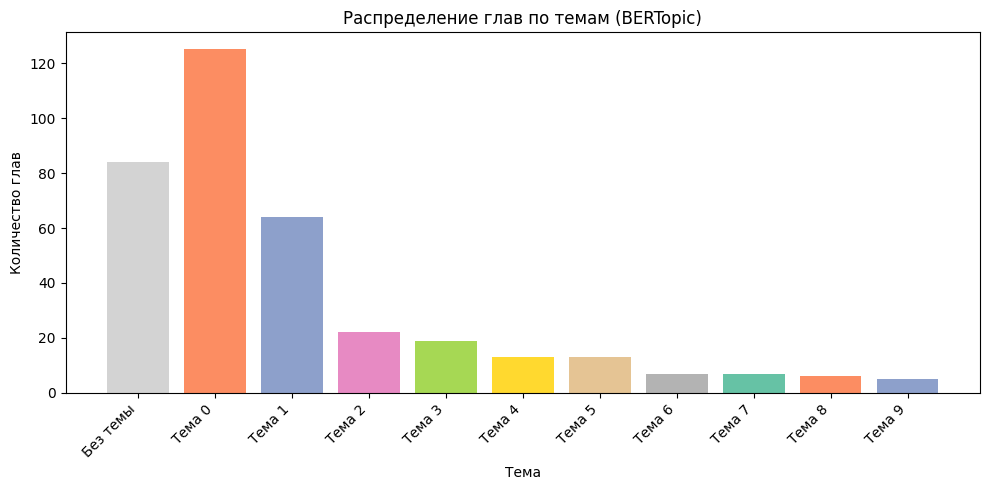

In [26]:
# Распределение тем
fig, ax = plt.subplots(figsize=(10, 5))
topic_counts = Counter(topics)

# Сортируем по номеру темы
sorted_topics = sorted(topic_counts.keys())
labels = [f'Тема {t}' if t >= 0 else 'Без темы' for t in sorted_topics]
counts = [topic_counts[t] for t in sorted_topics]
colors = ['lightgray' if t == -1 else plt.cm.Set2(i % 8) for i, t in enumerate(sorted_topics)]

ax.bar(labels, counts, color=colors)
ax.set_xlabel('Тема')
ax.set_ylabel('Количество глав')
ax.set_title('Распределение глав по темам (BERTopic)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.5. Привязка тем к книгам

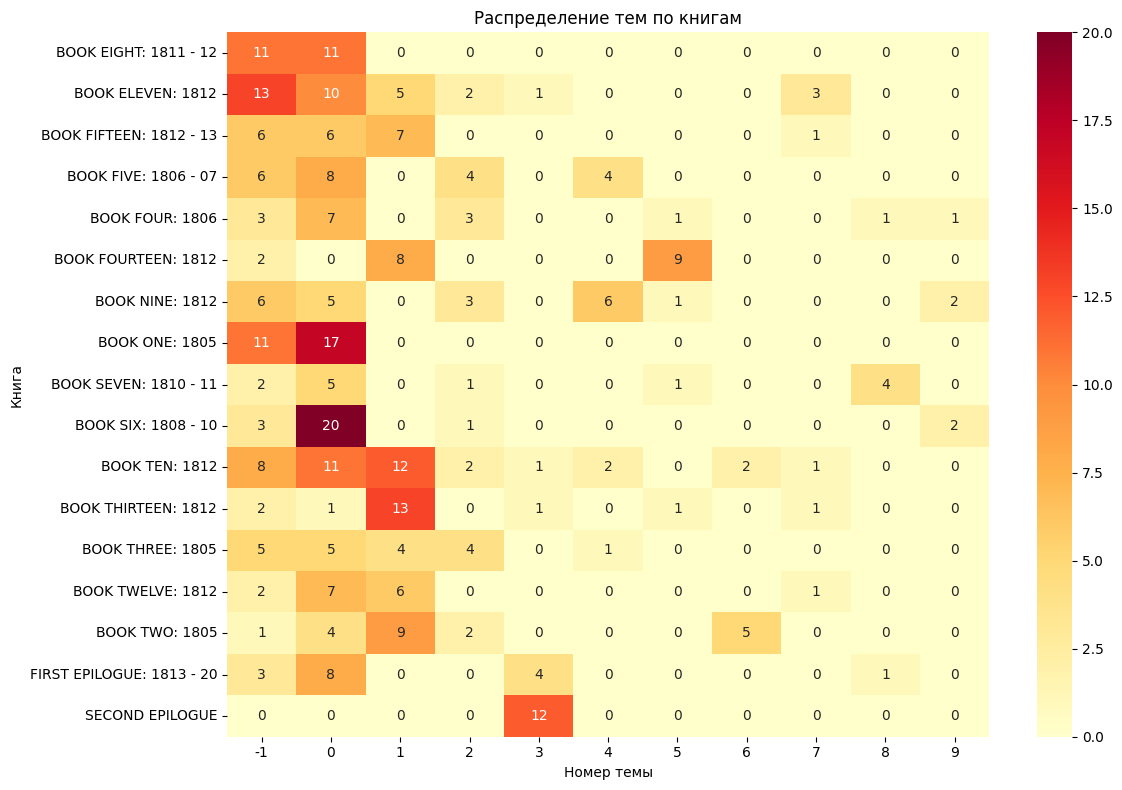

In [27]:
# Создаем датафрейм с результатами тематического моделирования
df_topics = df_chapters[['book', 'chapter']].copy()
df_topics['topic'] = topics

# Кросс-таблица: книги x темы
ct = pd.crosstab(df_topics['book'], df_topics['topic'])

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Распределение тем по книгам')
ax.set_xlabel('Номер темы')
ax.set_ylabel('Книга')
plt.tight_layout()
plt.show()

---
## Часть 7. Сводный анализ

Объединим результаты всех этапов в единую таблицу для первых 5 глав.
Таблица показывает, какие сущности, ключевые слова, суммаризации и темы
были извлечены для каждой главы.

In [28]:
# Сводная таблица
rows_summary = []
for i in range(len(sample_chapters)):
    row = {
        'Книга': all_entities_by_chapter[i]['book'],
        'Глава': all_entities_by_chapter[i]['chapter'],
        'Персоны (NER)': ', '.join(
            [p for p, _ in all_entities_by_chapter[i]['entities'].get('PER', Counter()).most_common(5)]
        ),
        'Ключевые слова': ', '.join(
            [kw for kw, _ in keywords_by_chapter[i]['keywords'][:5]]
        ),
        'Суммаризация': summaries_by_chapter[i]['summary'][:120] + '...',
        'Тема': topics[i]
    }
    rows_summary.append(row)

df_full = pd.DataFrame(rows_summary)
df_full

,Книга,Глава,Персоны (NER),Ключевые слова,Суммаризация,Тема
0,BOOK ONE: 1805,CHAPTER I,"Anna Pá, ##lov, Anna Pávlov, ##le, Novosílts","anna pávlovna, criticize empress, slave fright...",", Count (or Prince), and you are no longer my ...",-1
1,BOOK ONE: 1805,CHAPTER II,"Anna Pá, ##lov, Pierre, Anna Pávlov, Mo","princess bolkónskaya, woman petersburg, vasíli...",", Anna Pávlovna observed these greetings with ...",-1
2,BOOK ONE: 1805,CHAPTER III,"Anna Pávlov, Anna Pá, ##lov, ##ène, Pierre","pávlovna guests, lady careworn, round mortemar...",gathered round Mortemart and Anna Pávlovna. Th...,-1
3,BOOK ONE: 1805,CHAPTER IV,"Pierre, ##li, Prince, Anna Pá, Vasí","princess husband, bolkónski speaking, pávlovna...",", Prince Andrew Bolkónski, the little princess...",0
4,BOOK ONE: 1805,CHAPTER V,"Pierre, Anna Pávlov, Andrew, Prince, ##lov","charming moscow, remarked prince, words italia...",", Pierre, “He ever was a hero, after the murde...",-1


---
## Самостоятельные задания

Выполните три задания ниже. Каждое задание оценивается отдельно.

**Общие требования:**
- Код должен быть работоспособным и запускаться сверху вниз без ошибок.
- Код должен содержать комментарии на русском языке.
- Все визуализации должны иметь подписи осей и заголовки.
- Результаты должны быть оформлены в виде таблиц (DataFrame) или графиков.
- После каждого задания напишите текстовый вывод (2-3 предложения) в markdown-ячейке.

### Задание 1. Расширенный NER-анализ первой книги

**Сложность:** средняя

**Контекст задачи.**
В предыдущих разделах мы применили NER только к 5 главам.
Теперь необходимо выполнить NER-анализ всей первой книги (Book One: 1805),
чтобы получить более полную картину упоминания персон и географических объектов.

**Постановка задачи.**

1. **Отфильтруйте** из `df_chapters` все главы, принадлежащие Book One.

2. **Примените** NER-пайплайн (`ner_pipeline`) к каждой главе Book One,
   используя функцию `extract_entities_from_text()`.

3. **Определите топ-5 персон** (PER) по общему количеству упоминаний во всей книге.

4. **Постройте линейный график** динамики упоминаний этих 5 персон по главам:
   - Ось X -- номер главы (1, 2, ..., N).
   - Ось Y -- количество упоминаний персоны в данной главе.
   - 5 линий, каждая -- одна персона.
   - Легенда с именами персон.

5. **Выведите таблицу** всех географических названий (LOC),
   найденных в Book One, отсортированную по убыванию частоты.
   Столбцы: название, количество упоминаний.

**Подсказки:**
- Для фильтрации: `df_book1 = df_chapters[df_chapters['book'].str.contains('BOOK ONE')]`
- Используйте функции `extract_entities_from_text()` и `group_entities()` из Части 3.

**Критерии оценки:**

| Критерий | Баллы |
|---|---|
| Корректная фильтрация и обработка всех глав Book One | 2 |
| Правильное определение топ-5 персон | 1 |
| Линейный график с подписями, легендой, читаемыми осями | 3 |
| Таблица географических названий с сортировкой | 2 |
| Текстовый вывод (содержательная интерпретация) | 2 |
| **Итого** | **10** |

Глав в первой книге: 28


,book,chapter,chapter_num,length
0,BOOK ONE: 1805,CHAPTER I,1,11666
1,BOOK ONE: 1805,CHAPTER II,2,7910
2,BOOK ONE: 1805,CHAPTER III,3,8730
3,BOOK ONE: 1805,CHAPTER IV,4,8164
4,BOOK ONE: 1805,CHAPTER V,5,11253


Топ-5 персон первой книги:


,person,mentions_total
0,Pierre,275
1,Prince,105
2,Andrew,105
3,Anna Mikháylov,98
4,Bo,95


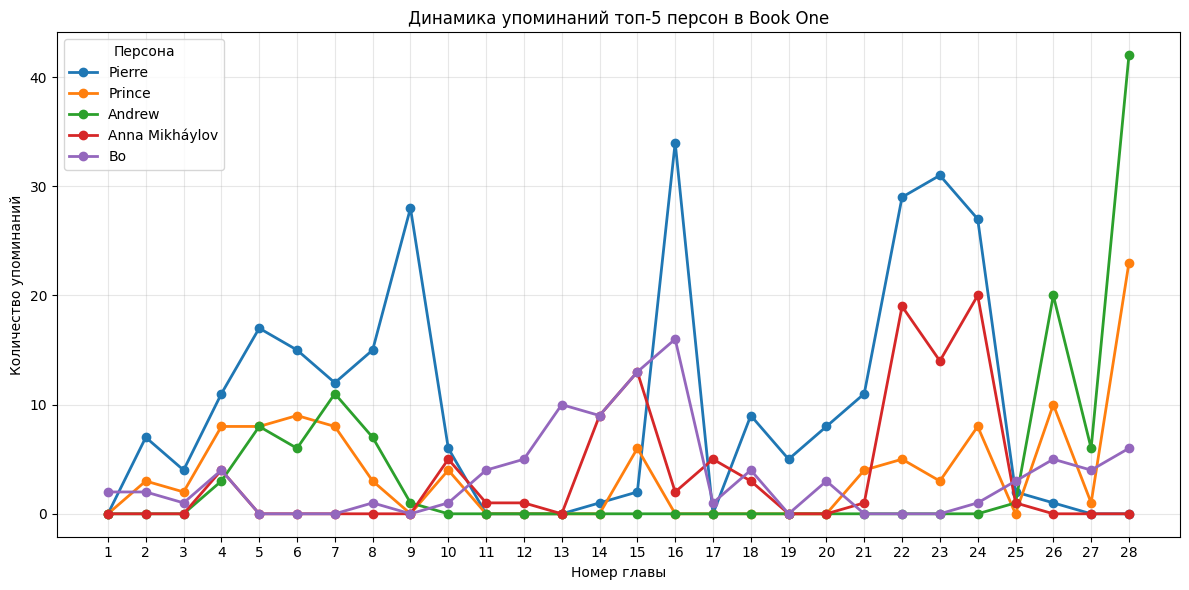

Географические названия (LOC) в Book One:


,location,mentions_total
0,Moscow,36
1,Petersburg,31
2,Russia,9
3,Europe,8
4,Prussia,7
...,...,...
58,##a Canal,1
59,Co,1
60,##z,1
61,##ov,1


In [ ]:
import re
from collections import Counter
from IPython.display import display

# Перевод римских чисел в арабские
def roman_to_int(roman):
    roman = roman.upper().strip()
    values = {'I': 1, 'V': 5, 'X': 10, 'L': 50, 'C': 100, 'D': 500, 'M': 1000}
    total = 0
    prev_value = 0
    for char in reversed(roman):
        value = values[char]
        if value < prev_value:
            total -= value
        else:
            total += value
            prev_value = value
    return total

# 1. Фильтрация глав первой книги
df_book1 = df_chapters[df_chapters['book'].str.contains(r'^BOOK ONE\b', case=False, na=False)].copy()

# Извлечение номера главы из строки вида "CHAPTER IV"
df_book1['chapter_num'] = (
    df_book1['chapter']
    .str.extract(r'CHAPTER\s+([IVXLC]+)', expand=False)
    .apply(roman_to_int)
)

# Сортировка главы в естественном порядке
df_book1 = df_book1.sort_values('chapter_num').reset_index(drop=True)

print(f'Глав в первой книге: {len(df_book1)}')
display(df_book1[['book', 'chapter', 'chapter_num', 'length']].head())

# 2. Применение NER к каждой главе первой книги
book1_entities_by_chapter = []

for _, row in df_book1.iterrows():
    # Извлечение именованных сущностей из текста главы
    entities_raw = extract_entities_from_text(row['text'], ner_pipeline) # Применяется пайплайн ner 

    # Группировка сущностей по типам (PER, LOC, ORG, ...)
    entities_grouped = group_entities(entities_raw)

    book1_entities_by_chapter.append({
        'chapter': row['chapter'],
        'chapter_num': row['chapter_num'],
        'entities': entities_grouped
    })

# 3. Топ-5 персон по суммарному числу упоминаний
all_book1_persons = Counter()
all_book1_locations = Counter()

for chapter_data in book1_entities_by_chapter:
    entities_grouped = chapter_data['entities']
    all_book1_persons.update(entities_grouped.get('PER', Counter()))
    all_book1_locations.update(entities_grouped.get('LOC', Counter()))

top5_persons = all_book1_persons.most_common(5)
top5_persons_df = pd.DataFrame(top5_persons, columns=['person', 'mentions_total'])

print('Топ-5 персон первой книги:')
display(top5_persons_df)

# 4. Линейный график динамики упоминаний этих персон по главам
top5_names = [name for name, _ in top5_persons]

mentions_by_chapter = []
for chapter_data in book1_entities_by_chapter:
    row_data = {'chapter_num': chapter_data['chapter_num']}
    per_counter = chapter_data['entities'].get('PER', Counter())
    for person_name in top5_names:
        row_data[person_name] = per_counter.get(person_name, 0)
    mentions_by_chapter.append(row_data)

df_mentions = pd.DataFrame(mentions_by_chapter).sort_values('chapter_num')

plt.figure(figsize=(12, 6))
for person_name in top5_names:
    plt.plot(
        df_mentions['chapter_num'],
        df_mentions[person_name],
        marker='o',
        linewidth=2,
        label=person_name
    )

plt.xlabel('Номер главы')
plt.ylabel('Количество упоминаний')
plt.title('Динамика упоминаний топ-5 персон в Book One')
plt.xticks(df_mentions['chapter_num'])
plt.legend(title='Персона')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Таблица географических названий (LOC), отсортированная по убыванию частоты
loc_table_book1 = (
    pd.DataFrame(all_book1_locations.items(), columns=['location', 'mentions_total'])
    .sort_values('mentions_total', ascending=False)
    .reset_index(drop=True)
)

print('Географические названия (LOC) в Book One:')
display(loc_table_book1)

**Вывод по Заданию 1:**  
NER-анализ всей первой книги позволяет увидеть самых часто упоминаемых персонажей и изменение их роли по мере развития сюжета от главы к главе. Линейный график показывает, что распределение упоминаний неравномерно: одни герои доминируют в нескольких главах подряд, а затем почти исчезают. Таблица локаций дополняет картину и помогает выделить важные географические точки, связанные с событиями первой книги.

### Задание 2. Сравнение ключевых слов между книгами

**Сложность:** средняя

**Контекст задачи.**
Каждая книга романа "Война и мир" посвящена определенному историческому периоду
и тематическому фокусу. Ключевые слова позволяют выявить эти различия
автоматически, без прочтения текста.

**Постановка задачи.**

1. **Для каждой книги** романа объедините тексты всех ее глав в один документ.

2. **Извлеките по 10 ключевых биграмм** из каждой книги с помощью KeyBERT:
   - `keyphrase_ngram_range=(2, 2)` -- только биграммы.
   - `stop_words='english'` -- исключение стоп-слов.
   - `use_mmr=True`, `diversity=0.5` -- диверсификация результатов.

3. **Постройте таблицу (DataFrame):**
   - Строки -- книги романа (Book One, Book Two, ...).
   - Столбцы -- ранги ключевых слов (1, 2, ..., 10).
   - Значения -- сами биграммы.

4. **Найдите общие биграммы** -- те, которые встречаются как ключевые
   в двух или более книгах. Выведите список таких биграмм
   с указанием, в каких книгах они присутствуют.

5. **Визуализируйте** результат: для 3 выбранных книг постройте
   горизонтальную столбчатую диаграмму ключевых слов со значениями
   cosine similarity (аналогично визуализации в Части 4).

**Подсказки:**
- Объединение текстов: `book_text = ' '.join(df_book['text'].tolist())`
- KeyBERT может работать с длинными текстами -- он обрезает их автоматически.

**Критерии оценки:**

| Критерий | Баллы |
|---|---|
| Корректное объединение текстов и извлечение биграмм для всех книг | 2 |
| Таблица ключевых слов (книги x ранги) | 2 |
| Нахождение общих биграмм с указанием книг | 2 |
| Визуализация (3 книги, горизонтальная столбчатая диаграмма) | 2 |
| Текстовый вывод (интерпретация различий между книгами) | 2 |
| **Итого** | **10** |

Всего книг/разделов для анализа: 17


,book
0,BOOK ONE: 1805
1,BOOK TWO: 1805
2,BOOK THREE: 1805
3,BOOK FOUR: 1806
4,BOOK FIVE: 1806 - 07


Таблица ключевых биграмм по книгам:


,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5,Rank 6,Rank 7,Rank 8,Rank 9,Rank 10
book,,,,,,,,,,
BOOK ONE: 1805,anna pávlovna,buonaparte prince,rostóvs invitation,explaining nicholas,slave frightened,emperor exclaimed,schérer quite,privately rudenesses,mouth issued,widow means
BOOK TWO: 1805,regiment inspected,1805 russian,reached braunau,general shouted,stand krems,approaching enemy,march resting,inhabitants quartered,reports position,order silent
BOOK THREE: 1805,prince vasíli,emperor thought,self confidence,attained longed,motive struggle,valets instinctively,men remarked,habit schemes,pierre useless,emulating father
BOOK FOUR: 1806,sleigh rostóv,moscow longer,denísov stayed,bogdánovna hastening,1806 nicholas,corner crossroads,count walked,delay doors,morning mean,horses visiting
BOOK FIVE: 1806 - 07,petersburg answered,sympathize pierre,borís lodging,selling torzhók,portmanteaus brought,denísov asleep,servant unpacking,stories potëmkin,station horses,room pondering
BOOK SIX: 1808 - 10,andrew estate,understand nicholas,cloister father,boguchárovo occupations,peasants household,napoleonic notabilities,salary prince,labor commuted,emperor neglect,liberating serfs
BOOK SEVEN: 1810 - 11,rostóv cheerful,idleness curse,denísov servant,man primitive,dignity cordiality,absence labor,running deserted,golukhovski bargaining,rejoin regiment,postponement marriage
BOOK EIGHT: 1811 - 12,prince happened,promised countess,wife natásha,relating andrew,borís engaged,nicholas symptoms,abandoning melancholy,rostóvs stayed,bonaparte despised,formalities life
BOOK NINE: 1812,1812 forces,regard crimes,meaning causes,induced alexander,rostóv feigned,act historical,europe began,recorded annals,medicines fear,men bagratión


Общие биграммы (встречаются в 2+ книгах):


,bigram,n_books,books


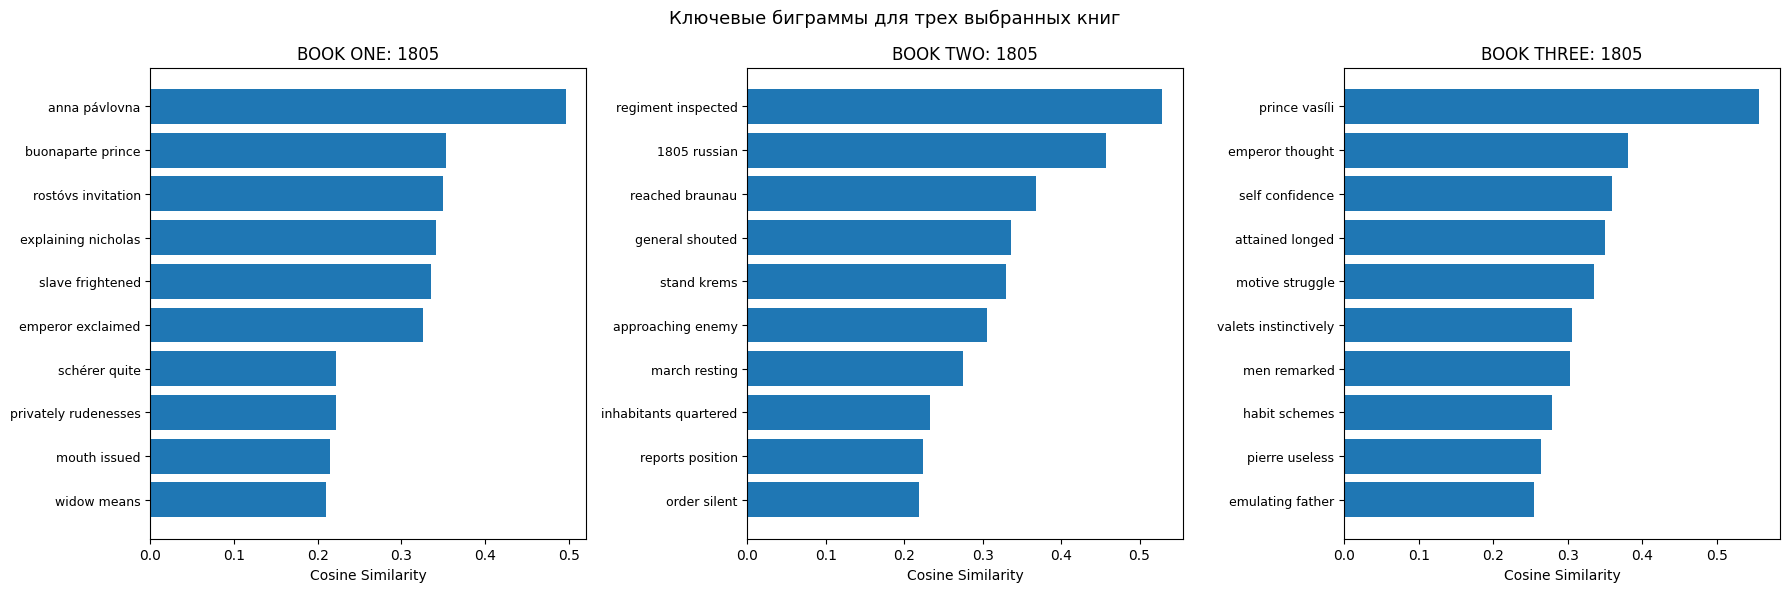

In [ ]:
from collections import defaultdict
from IPython.display import display

# 1. Для каждой книги объединяются тексты всех ее глав в один документ
book_texts = (
    df_chapters
    .groupby('book', sort=False)['text']
    .apply(lambda texts: ' '.join(texts.tolist()))
    .reset_index(name='book_text')
)

print(f'Всего книг/разделов для анализа: {len(book_texts)}')
display(book_texts[['book']].head())

# 2. Извлечение по 10 ключевых биграмм из каждой книги
keywords_by_book = {}

for _, row in book_texts.iterrows():
    book_name = row['book']
    book_text = row['book_text']

    keywords = kw_model.extract_keywords( # Используется библиотека KeyBERT, внутри нее SentenceTransformer all-MiniLM-L6-v2
        book_text,
        keyphrase_ngram_range=(2, 2), # Только биграммы
        stop_words='english',
        top_n=10,
        use_mmr=True, # чтобы выбирать слова и важные, и разные
        diversity=0.5 # БАланс важности и разнообразия
    )
    keywords_by_book[book_name] = keywords

# 3. Таблица рангов ключевых биграмм
keyword_table_data = {}
for book_name, keywords in keywords_by_book.items():
    keyword_table_data[book_name] = {rank: kw for rank, (kw, _) in enumerate(keywords, start=1)}

df_keyword_ranks = (
    pd.DataFrame.from_dict(keyword_table_data, orient='index')
    .rename_axis('book')
)

# Переименовывка столбцов для большей наглядности
df_keyword_ranks.columns = [f'Rank {col}' for col in df_keyword_ranks.columns]

print('Таблица ключевых биграмм по книгам:')
display(df_keyword_ranks)

# 4. Поиск биграмм, которые встречаются в двух и более книгах
bigram_to_books = defaultdict(list)

for book_name, keywords in keywords_by_book.items():
    for bigram, _ in keywords:
        bigram_to_books[bigram].append(book_name)

common_bigrams_rows = []
for bigram, books_list in bigram_to_books.items():
    unique_books = sorted(set(books_list))
    if len(unique_books) >= 2:
        common_bigrams_rows.append({
            'bigram': bigram,
            'n_books': len(unique_books),
            'books': ', '.join(unique_books)
        })

df_common_bigrams = (
    pd.DataFrame(common_bigrams_rows)
    .sort_values(['n_books', 'bigram'], ascending=[False, True])
    .reset_index(drop=True)
    if common_bigrams_rows else
    pd.DataFrame(columns=['bigram', 'n_books', 'books'])
)

print('Общие биграммы (встречаются в 2+ книгах):')
display(df_common_bigrams)

# 5. Визуализация: для 3 выбранных книг горизонтальные диаграммы
selected_books = list(book_texts['book'].head(3))

fig, axes = plt.subplots(1, len(selected_books), figsize=(18, 6), squeeze=False)
axes = axes.ravel()

for ax, book_name in zip(axes, selected_books):
    keywords = keywords_by_book[book_name]
    bigrams = [kw for kw, _ in keywords]
    scores = [score for _, score in keywords]

    ax.barh(range(len(bigrams)), scores)
    ax.set_yticks(range(len(bigrams)))
    ax.set_yticklabels(bigrams, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Cosine Similarity')
    ax.set_title(book_name)

plt.suptitle('Ключевые биграммы для трех выбранных книг', fontsize=13)
plt.tight_layout()
plt.show()

**Вывод:**  
Сравнение ключевых биграмм показывает то, что разные книги романа обладают собственным тематическим профилем, который автоматически выявляется с помощью KeyBERT. Общие биграммы позволяют заметить повторяющиеся мотивы и сквозные сюжетные линии, связывающие несколько книг. Визуализация для трех выбранных книг делает различия между их смысловыми акцентами наглядными и удобными для интерпретации.

### Задание 3. Суммаризация и тематический анализ выбранной книги

**Сложность:** повышенная

**Контекст задачи.**
Это задание объединяет суммаризацию и тематическое моделирование
в рамках одной книги романа. Цель -- получить сжатое представление
о содержании книги и выделить ее внутреннюю тематическую структуру.

**Постановка задачи.**

1. **Выберите одну книгу** романа. Рекомендуемые варианты:
   - Book Ten: 1812 (начало войны 1812 года, вторжение Наполеона).
   - Book Twelve: 1812 (Москва, пожар, отступление).
   - Book Fifteen: 1812-13 (партизанская война, развязка).

2. **Суммаризируйте каждую главу** выбранной книги
   с помощью функции `summarize_long_text()`.
   Выведите таблицу: номер главы, первые 100 символов суммаризации, длина.

3. **Примените BERTopic** к главам выбранной книги:
   - Каждая глава -- один документ.
   - Поскольку в одной книге ~15-25 глав, установите `min_cluster_size=2` или `3`.
   - Если HDBSCAN помечает слишком много документов как шум (-1),
     попробуйте уменьшить `min_samples=1`.

4. **Постройте 2D-визуализацию** (scatter plot):
   - Получите эмбеддинги глав: `embeddings = embedding_model.encode(docs_selected)`.
   - Спроецируйте в 2D: `umap_2d = UMAP(n_components=2, random_state=42).fit_transform(embeddings)`.
   - Каждая глава -- точка, окрашенная по теме.
   - Подпишите точки номерами глав (plt.annotate или plt.text).

5. **Выведите ключевые слова** каждой найденной темы
   (используйте `topic_model.get_topic(topic_id)`).

6. **Напишите интерпретацию:**
   - Какие тематические кластеры выделяются?
   - Какие главы тематически близки?
   - Совпадает ли результат с известным содержанием книги?

**Подсказки:**
```python
from umap import UMAP

# Получение эмбеддингов
embeddings = embedding_model.encode(docs_selected)

# UMAP-проекция в 2D
umap_2d = UMAP(n_components=2, random_state=42).fit_transform(embeddings)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(umap_2d[:, 0], umap_2d[:, 1], c=topics_selected, cmap='Set2', s=100)
for i, label in enumerate(chapter_labels):
    ax.annotate(label, (umap_2d[i, 0], umap_2d[i, 1]), fontsize=8)
```

**Критерии оценки:**

| Критерий | Баллы |
|---|---|
| Корректная суммаризация всех глав выбранной книги | 2 |
| Таблица суммаризаций с читаемым форматированием | 1 |
| Корректное применение BERTopic (настройка параметров) | 2 |
| 2D-визуализация с окраской по темам и подписями глав | 2 |
| Ключевые слова тем | 1 |
| Содержательная интерпретация (3-5 предложений) | 2 |
| **Итого** | **10** |

Выбранная книга: BOOK TEN: 1812
Количество глав: 39
Таблица суммаризаций по главам:


,chapter_num,summary_100_chars,summary_length
0,1,", and all were involuntary tools of history, c...",493
1,2,"Prince Andrew. “Go and get it for me,” said Ma...",500
2,3,"Alpátych who stood by the door, he gave his in...",1103
3,4,yákov Alpátych. “What I say is: Orders have be...,360
4,5,"and wheels, and the infantry sank ankle-deep i...",427
5,6,– and saw in them and in the sub were admitted...,334
6,7,was taking place in Petersburg the French had ...,457
7,8,", and wished not to say anything. Princess Mar...",485
8,9,"Alpátych noticed an undercurrents, and that co...",418
9,10,"General Rameau’s, telling people not to leave ...",460


Batches: 100%|██████████| 2/2 [00:00<00:00,  2.07it/s]


Распределение тем по главам:


,chapter_num,chapter,topic
0,1,CHAPTER I,1
1,2,CHAPTER II,2
2,3,CHAPTER III,4
3,4,CHAPTER IV,2
4,5,CHAPTER V,5
5,6,CHAPTER VI,6
6,7,CHAPTER VII,1
7,8,CHAPTER VIII,2
8,9,CHAPTER IX,2
9,10,CHAPTER X,3


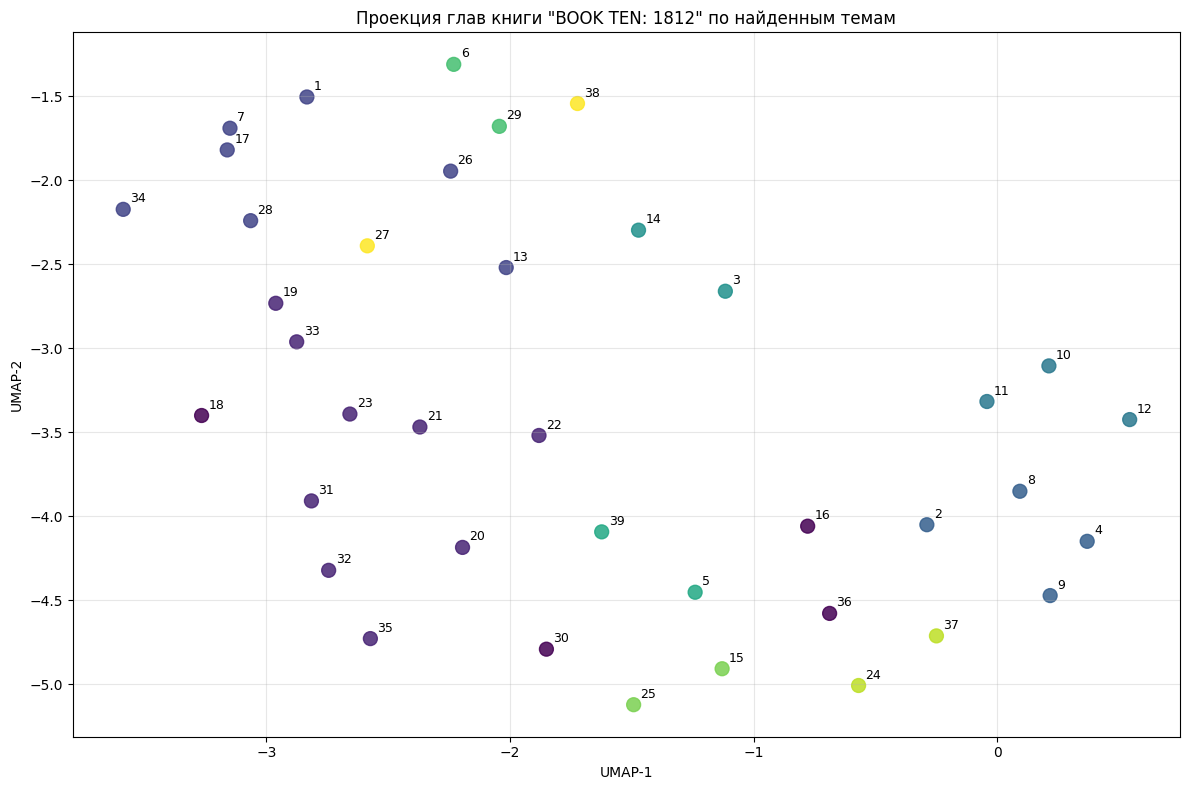

Ключевые слова найденных тем:


,topic_id,n_chapters,keywords
0,-1,4,"the, and, to, he, of, in, his, that, was, it"
1,0,9,"the, and, of, to, pierre, was, on, that, in, he"
2,1,7,"the, to, of, and, napoleon, that, was, his, in..."
3,2,4,"the, and, to, her, of, his, he, alpátych, in, had"
4,3,3,"she, her, to, princess, and, the, mary, you, t..."
5,4,2,"the, to, and, it, he, his, her, you, with, that"
6,5,2,"the, and, of, to, that, prince, had, his, in, not"
7,6,2,"the, of, pávlovna, anna, in, and, to, he, vasí..."
8,7,2,"and, he, the, of, andrew, that, to, prince, hi..."
9,8,2,"and, his, he, the, andrew, of, to, him, prince..."


In [ ]:
from IPython.display import display
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

# 1. Выбор книги для анализа
preferred_books = ['BOOK TEN', 'BOOK TWELVE', 'BOOK FIFTEEN']
selected_book_name = None

for book_prefix in preferred_books: # Ищет в датасете
    matched_books = [book for book in df_chapters['book'].unique() if book.startswith(book_prefix)]
    if matched_books:
        selected_book_name = matched_books[0]
        break

# Если рекомендованных книг в данных нет, взять первую доступную книгу
if selected_book_name is None:
    selected_book_name = df_chapters['book'].iloc[0]

# Фильтрация главы выбранной книги
df_selected_book = df_chapters[df_chapters['book'] == selected_book_name].copy()

# Добавление числовой номер главы
df_selected_book['chapter_num'] = (
    df_selected_book['chapter']
    .str.extract(r'CHAPTER\s+([IVXLC]+)', expand=False)
    .apply(roman_to_int)
)

df_selected_book = df_selected_book.sort_values('chapter_num').reset_index(drop=True)

print(f'Выбранная книга: {selected_book_name}')
print(f'Количество глав: {len(df_selected_book)}')

# 2. Суммаризация каждой главы выбранной книги
chapter_summaries = []

for _, row in df_selected_book.iterrows():
    summary = summarize_long_text(
        row['text'],
        sum_tokenizer,
        sum_model,
        max_chunk_chars=1500,
        max_new_tokens=80,
        min_length=20
    )
    chapter_summaries.append({
        'chapter_num': row['chapter_num'],
        'summary': summary,
        'summary_100_chars': summary[:100],
        'summary_length': len(summary)
    })

df_summaries = pd.DataFrame(chapter_summaries)

print('Таблица суммаризаций по главам:')
display(df_summaries[['chapter_num', 'summary_100_chars', 'summary_length']])

# 3. Применение BERTopic к главам выбранной книги
docs_selected = df_selected_book['text'].tolist()

# Подбор параметров
n_docs = len(docs_selected)
umap_n_neighbors = max(2, min(10, n_docs - 1))
umap_n_components = max(2, min(5, n_docs - 2 if n_docs > 2 else 2))

umap_model_selected = UMAP(
    n_neighbors=umap_n_neighbors,
    n_components=umap_n_components,
    min_dist=0.0,
    metric='cosine',
    random_state=SEED
)

hdbscan_model_selected = HDBSCAN(
    min_cluster_size=2,
    min_samples=1,
    metric='euclidean',
    prediction_data=True
)

topic_model_selected = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model_selected,
    hdbscan_model=hdbscan_model_selected,
    nr_topics='auto',
    verbose=False
)

# Тематическое моделирование
# Сначала идет получение эмбеддингов глав, затем это засовывается в предобученную модель
embeddings = embedding_model.encode(docs_selected, show_progress_bar=True)
topics_selected, probs_selected = topic_model_selected.fit_transform(docs_selected, embeddings) # Ключевые слова с кластеризацией и tf-idf

df_topics = df_selected_book[['chapter_num', 'chapter']].copy()
df_topics['topic'] = topics_selected

print('Распределение тем по главам:')
display(df_topics)

# 4. Визуализация
umap_2d = UMAP(n_components=2, random_state=42)
embeddings_2d = umap_2d.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=topics_selected,
    s=100,
    alpha=0.85
)

for _, row in df_topics.iterrows():
    idx = row.name
    plt.annotate(
        str(row['chapter_num']),
        (embeddings_2d[idx, 0], embeddings_2d[idx, 1]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.title(f'Проекция глав книги "{selected_book_name}" по найденным темам')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Ключевые слова каждой найденной темы
unique_topics = sorted(set(topics_selected))

topic_keywords_rows = []
for topic_id in unique_topics:
    topic_words = topic_model_selected.get_topic(topic_id)

    if topic_words is None:
        keywords_str = ''
    else:
        keywords_str = ', '.join([word for word, _ in topic_words[:10]])

    topic_keywords_rows.append({
        'topic_id': topic_id,
        'n_chapters': int((df_topics['topic'] == topic_id).sum()),
        'keywords': keywords_str
    })

df_topic_keywords = pd.DataFrame(topic_keywords_rows)

print('Ключевые слова найденных тем:')
display(df_topic_keywords)

**Вывод по Заданию 3:**  
Суммаризация по главам дает компактное представление о содержании выбранной книги и помогает быстро оценить, как развивается повествование от начала к концу. Тематическое моделирование BERTopic показывает, что даже внутри одной книги главы могут группироваться в несколько устойчивых смысловых кластеров, связанных с разными сюжетными линиями. Двумерная проекция эмбеддингов позволяет визуально проверить, насколько близки главы одной темы друг к другу и есть ли среди них изолированные эпизоды. Ключевые слова тем делают интерпретацию полученных кластеров более прозрачной и связывают их с конкретными мотивами романа.

---
## Использованные модели и библиотеки

| Компонент | Модель / Библиотека | Источник |
|---|---|---|
| NER | `dslim/bert-base-NER` | https://huggingface.co/dslim/bert-base-NER |
| Эмбеддинги | `all-MiniLM-L6-v2` | https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2 |
| Ключевые слова | KeyBERT | https://github.com/MaartenGr/KeyBERT |
| Суммаризация | `Falconsai/text_summarization` (T5-small) | https://huggingface.co/Falconsai/text_summarization |
| Темы | BERTopic | https://github.com/MaartenGr/BERTopic |
| Текст | "War and Peace" (Tolstoy) | https://www.gutenberg.org/ebooks/2600 |

## Литература

1. Devlin J., Chang M.-W., Lee K., Toutanova K. BERT: Pre-training of Deep Bidirectional
   Transformers for Language Understanding. NAACL-HLT, 2019.
2. Vaswani A. et al. Attention Is All You Need. NeurIPS, 2017.
3. Raffel C. et al. Exploring the Limits of Transfer Learning with a Unified
   Text-to-Text Transformer (T5). JMLR, 2020.
4. Reimers N., Gurevych I. Sentence-BERT: Sentence Embeddings using Siamese
   BERT-Networks. EMNLP, 2019.
5. Grootendorst M. KeyBERT: Minimal keyword extraction with BERT. 2020.
   https://github.com/MaartenGr/KeyBERT
6. Grootendorst M. BERTopic: Neural topic modeling with a class-based TF-IDF
   procedure. arXiv:2203.05794, 2022.
7. Sang E.F.T.K., De Meulder F. Introduction to the CoNLL-2003 Shared Task:
   Language-Independent Named Entity Recognition. CoNLL, 2003.
8. McInnes L., Healy J., Melville J. UMAP: Uniform Manifold Approximation
   and Projection for Dimension Reduction. arXiv:1802.03426, 2018.
9. Campello R.J.G.B., Moulavi D., Sander J. Density-Based Clustering Based on
   Hierarchical Density Estimates (HDBSCAN). PAKDD, 2013.
10. Blei D.M., Ng A.Y., Jordan M.I. Latent Dirichlet Allocation. JMLR, 2003.